# miRNA Periodontal Disease Analysis: Comprehensive Jupyter Notebook

## Project Overview
This notebook performs comprehensive analysis of miRNA expression data to identify biomarkers for periodontal disease progression (Healthy → Gingivitis → Periodontitis).

**Key Features:**
- ΔΔCt transformation pipeline with GAPDH reference normalization
- Statistical analysis with FDR correction and effect size calculations
- Machine learning classification models with cross-validation
- Dimensionality reduction and clustering validation
- Comprehensive visualization suite with organized outputs

**Authors:** AI-driven Analytical Scientists  
**Date:** July 16, 2025  
**Dataset:** miRNA-saliva-qPCR-results.csv (103 samples, 14 variables)

---

## Analysis Workflow
1. **Environment Setup** - Library imports and configuration
2. **Data Loading & Preprocessing** - Data quality checks and transformations
3. **Exploratory Data Analysis** - Descriptive statistics and initial insights
4. **Statistical Analysis** - Hypothesis testing and differential expression
5. **Machine Learning Models** - Classification and predictive modeling
6. **Dimensionality Reduction** - PCA, t-SNE, UMAP analysis
7. **Visualization Generation** - Comprehensive plotting suite
8. **Results Export** - Organized output structure with Title Case naming

# 1. Environment Setup and Configuration

Setting up the analysis environment with all required libraries and output directory structure.

In [1]:
#!/usr/bin/env python3
"""
miRNA Periodontal Disease Analysis - Comprehensive Jupyter Notebook
================================================================

This notebook performs comprehensive analysis of miRNA expression data to identify
biomarkers for periodontal disease progression (Healthy → Gingivitis → Periodontitis).
"""

# Core scientific computing
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Statistical analysis
from scipy import stats
from scipy.stats import (
    levene,
    shapiro,
    kruskal,
    mannwhitneyu,
    ttest_ind,
    chi2_contingency,
    pearsonr,
    spearmanr,
)
import statsmodels.stats.multitest as smt

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
)
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Dimensionality reduction
import umap

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Additional utilities
import os
import logging
from datetime import datetime
import json
import sys

# Configure logging
logger = logging.getLogger()  # Get the root logger
logger.setLevel(logging.INFO)

# Clear any handlers that may already be configured to avoid duplicate logs
if logger.hasHandlers():
    logger.handlers.clear()

# Define a standard format for log messages
formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")

# Create a file handler to write logs to 'analysis.log' using UTF-8 encoding
# The 'w' mode ensures the log file is overwritten each time the script runs
file_handler = logging.FileHandler("analysis.log", mode="w", encoding="utf-8")
file_handler.setFormatter(formatter)

# Create a stream handler to print logs to the console using UTF-8 encoding
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(formatter)

# Add both handlers to the logger
logger.addHandler(file_handler)
logger.addHandler(stream_handler)

# The logger is now configured. The rest of your code can use it as before.
logger = logging.getLogger(__name__)

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Configure matplotlib and seaborn
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print("✅ Environment setup complete!")
print(f"📊 Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🐍 Python version: {sys.version}")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 NumPy version: {np.__version__}")


✅ Environment setup complete!
📊 Analysis started at: 2025-07-17 00:02:17
🐍 Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
📊 Pandas version: 2.3.1
📈 NumPy version: 2.2.6


In [2]:
# Configure output directory structure
BASE_OUTPUT_DIR = "outputs/jupyter_notebook"
OUTPUT_DIRS = {
    "base": BASE_OUTPUT_DIR,
    "plots": f"{BASE_OUTPUT_DIR}/plots",
    "tables": f"{BASE_OUTPUT_DIR}/tables",
    "sensitivity": f"{BASE_OUTPUT_DIR}/sensitivity",
}

# Create output directories
for dir_name, dir_path in OUTPUT_DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"📁 Created directory: {dir_path}")


# Define file naming conventions
def get_output_path(filename, output_type="plots"):
    """Get standardized output path with Title Case naming"""
    if not filename.endswith((".png", ".jpg", ".jpeg", ".pdf", ".csv", ".txt")):
        filename += ".png"  # Default to PNG for plots

    return os.path.join(OUTPUT_DIRS[output_type], filename)


# Analysis configuration
ANALYSIS_CONFIG = {
    "random_state": 42,
    "test_size": 0.2,
    "cv_folds": 5,
    "alpha_level": 0.05,
    "fdr_method": "fdr_bh",
    "effect_size_threshold": 1.0,
    "groups": ["S", "G", "P"],  # Healthy, Gingivitis, Periodontitis
    "mirna_targets": [
        "mean_mir146a",
        "mean_mir146b",
        "mean_mir155",
        "mean_mir203",
        "mean_mir223",
        "mean_mir381p",
    ],
    "mirna_names": [
        "mir146a",
        "mir146b",
        "mir155",
        "mir203",
        "mir223",
        "mir381p",
    ],  # Clean names for derived columns
    "clinical_vars": [
        "plaque_index",
        "gingival_index",
        "pocket_depth",
        "bleeding_on_probing",
        "number_of_missing_teeth",
    ],
    "demographic_vars": ["AGE", "SEX"],
}

print("🔧 Configuration complete!")
print(f"📊 Analysis parameters: {json.dumps(ANALYSIS_CONFIG, indent=2)}")


📁 Created directory: outputs/jupyter_notebook
📁 Created directory: outputs/jupyter_notebook/plots
📁 Created directory: outputs/jupyter_notebook/tables
📁 Created directory: outputs/jupyter_notebook/sensitivity
🔧 Configuration complete!
📊 Analysis parameters: {
  "random_state": 42,
  "test_size": 0.2,
  "cv_folds": 5,
  "alpha_level": 0.05,
  "fdr_method": "fdr_bh",
  "effect_size_threshold": 1.0,
  "groups": [
    "S",
    "G",
    "P"
  ],
  "mirna_targets": [
    "mean_mir146a",
    "mean_mir146b",
    "mean_mir155",
    "mean_mir203",
    "mean_mir223",
    "mean_mir381p"
  ],
  "mirna_names": [
    "mir146a",
    "mir146b",
    "mir155",
    "mir203",
    "mir223",
    "mir381p"
  ],
  "clinical_vars": [
    "plaque_index",
    "gingival_index",
    "pocket_depth",
    "bleeding_on_probing",
    "number_of_missing_teeth"
  ],
  "demographic_vars": [
    "AGE",
    "SEX"
  ]
}


# 2. Data Loading and Preprocessing

Loading the miRNA-saliva-qPCR dataset and performing essential data quality checks and transformations.

In [3]:
# Load the dataset
DATA_FILE = "miRNA-saliva-qPCR-results.csv"
logger.info(f"Loading data from {DATA_FILE}")

try:
    df = pd.read_csv(DATA_FILE)
    logger.info("✅ Data loaded successfully")
except FileNotFoundError:
    logger.error(f"❌ File {DATA_FILE} not found!")
    raise
except Exception as e:
    logger.error(f"❌ Error loading data: {e}")
    raise

# Data validation and quality checks
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Groups: {df['GROUP'].value_counts().to_dict()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Check for missing values
print("\n🔍 DATA QUALITY ASSESSMENT")
print("=" * 50)
missing_data = df.isnull().sum()
if missing_data.any():
    print("Missing values detected:")
    print(missing_data[missing_data > 0])
else:
    print("✅ No missing values detected")

# Data types and basic statistics
print("\n📋 DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n📊 BASIC STATISTICS")
print("=" * 50)
print(df.describe())

# Validate group codes
expected_groups = {"S", "G", "P"}
actual_groups = set(df["GROUP"].unique())
if actual_groups != expected_groups:
    logger.warning(
        f"⚠️  Group codes mismatch. Expected: {expected_groups}, Found: {actual_groups}"
    )
else:
    logger.info("✅ Group codes validated")

# Display first few rows
print("\n📖 SAMPLE DATA")
print("=" * 50)
print(df.head())


2025-07-17 00:02:17,040 - INFO - Loading data from miRNA-saliva-qPCR-results.csv
2025-07-17 00:02:17,050 - INFO - ✅ Data loaded successfully
2025-07-17 00:02:17,050 - INFO - ✅ Data loaded successfully
📊 DATASET OVERVIEW
Shape: (108, 15)
Columns: ['GROUP', 'SEX', 'AGE', 'plaque_index', 'gingival_index', 'pocket_depth', 'bleeding_on_probing', 'number_of_missing_teeth', 'mean_mir146a', 'mean_mir146b', 'mean_mir155', 'mean_mir203', 'mean_mir223', 'mean_mir381p', 'mean_GAPDH']
Groups: {'S': 36, 'G': 36, 'P': 36}
Memory usage: 23.33 KB

🔍 DATA QUALITY ASSESSMENT
✅ No missing values detected

📋 DATA TYPES
GROUP                       object
SEX                         object
AGE                          int64
plaque_index               float64
gingival_index             float64
pocket_depth               float64
bleeding_on_probing        float64
number_of_missing_teeth      int64
mean_mir146a               float64
mean_mir146b               float64
mean_mir155                float64
mean_mir2

In [4]:
# ΔΔCt Transformation Pipeline
print("🧬 PERFORMING ΔΔCt TRANSFORMATION")
print("=" * 50)

# Step 1: Calculate ΔCt (Ct_miRNA - Ct_GAPDH)
print("Step 1: Calculating ΔCt values...")
for mirna in ANALYSIS_CONFIG["mirna_targets"]:
    # Create clean miRNA name for derived columns
    clean_mirna = mirna.replace("mean_", "")
    dct_col = f"dCt_{clean_mirna}"
    df[dct_col] = df[mirna] - df["mean_GAPDH"]
    print(f"  ✓ {dct_col} = {mirna} - mean_GAPDH")

# Step 2: Calculate calibrator values (mean ΔCt for Healthy group)
print("\nStep 2: Calculating calibrator values (Healthy group means)...")
healthy_group = df[df["GROUP"] == "S"]
calibrators = {}

for mirna in ANALYSIS_CONFIG["mirna_targets"]:
    clean_mirna = mirna.replace("mean_", "")
    dct_col = f"dCt_{clean_mirna}"
    calibrator_value = healthy_group[dct_col].mean()
    calibrators[clean_mirna] = calibrator_value
    print(f"  ✓ Calibrator for {clean_mirna}: {calibrator_value:.3f}")

# Step 3: Calculate ΔΔCt (ΔCt_sample - ΔCt_calibrator)
print("\nStep 3: Calculating ΔΔCt values...")
for mirna in ANALYSIS_CONFIG["mirna_targets"]:
    clean_mirna = mirna.replace("mean_", "")
    dct_col = f"dCt_{clean_mirna}"
    ddct_col = f"ddCt_{clean_mirna}"
    df[ddct_col] = df[dct_col] - calibrators[clean_mirna]
    print(f"  ✓ {ddct_col} = {dct_col} - {calibrators[clean_mirna]:.3f}")

# Step 4: Calculate RQ values (2^(-ΔΔCt))
print("\nStep 4: Calculating RQ values (2^(-ΔΔCt))...")
for mirna in ANALYSIS_CONFIG["mirna_targets"]:
    clean_mirna = mirna.replace("mean_", "")
    ddct_col = f"ddCt_{clean_mirna}"
    rq_col = f"RQ_{clean_mirna}"
    df[rq_col] = 2 ** (-df[ddct_col])
    print(f"  ✓ {rq_col} = 2^(-{ddct_col})")

# Save calibrator values
calibrator_df = pd.DataFrame([calibrators]).T
calibrator_df.columns = ["Calibrator_Value"]
calibrator_df.index.name = "miRNA"
calibrator_df.to_csv(get_output_path("Calibration_Table.csv", "tables"))

print("✅ ΔΔCt transformation complete!")
print(
    f"📊 Calibrator values saved to: {get_output_path('Calibration_Table.csv', 'tables')}"
)

# Display transformation results
print("\n📊 TRANSFORMATION RESULTS PREVIEW")
print("=" * 50)
transformation_cols = ["GROUP"] + [
    f"RQ_{mirna.replace('mean_', '')}" for mirna in ANALYSIS_CONFIG["mirna_targets"]
]
print(df[transformation_cols].head(10))


🧬 PERFORMING ΔΔCt TRANSFORMATION
Step 1: Calculating ΔCt values...
  ✓ dCt_mir146a = mean_mir146a - mean_GAPDH
  ✓ dCt_mir146b = mean_mir146b - mean_GAPDH
  ✓ dCt_mir155 = mean_mir155 - mean_GAPDH
  ✓ dCt_mir203 = mean_mir203 - mean_GAPDH
  ✓ dCt_mir223 = mean_mir223 - mean_GAPDH
  ✓ dCt_mir381p = mean_mir381p - mean_GAPDH

Step 2: Calculating calibrator values (Healthy group means)...
  ✓ Calibrator for mir146a: 0.435
  ✓ Calibrator for mir146b: 0.491
  ✓ Calibrator for mir155: 0.445
  ✓ Calibrator for mir203: 0.935
  ✓ Calibrator for mir223: 0.930
  ✓ Calibrator for mir381p: 0.956

Step 3: Calculating ΔΔCt values...
  ✓ ddCt_mir146a = dCt_mir146a - 0.435
  ✓ ddCt_mir146b = dCt_mir146b - 0.491
  ✓ ddCt_mir155 = dCt_mir155 - 0.445
  ✓ ddCt_mir203 = dCt_mir203 - 0.935
  ✓ ddCt_mir223 = dCt_mir223 - 0.930
  ✓ ddCt_mir381p = dCt_mir381p - 0.956

Step 4: Calculating RQ values (2^(-ΔΔCt))...
  ✓ RQ_mir146a = 2^(-ddCt_mir146a)
  ✓ RQ_mir146b = 2^(-ddCt_mir146b)
  ✓ RQ_mir155 = 2^(-ddCt_mir15

🔬 REFERENCE GENE VALIDATION
GAPDH stability by group:
            mean       std  count
GROUP                            
G      35.905185  2.017755     36
P      31.387870  0.373077     36
S      36.492222  0.469061     36

Kruskal-Wallis test for GAPDH stability:
H-statistic: 60.714
p-value: 0.000
⚠️  GAPDH shows significant variation across groups - proceed with caution!


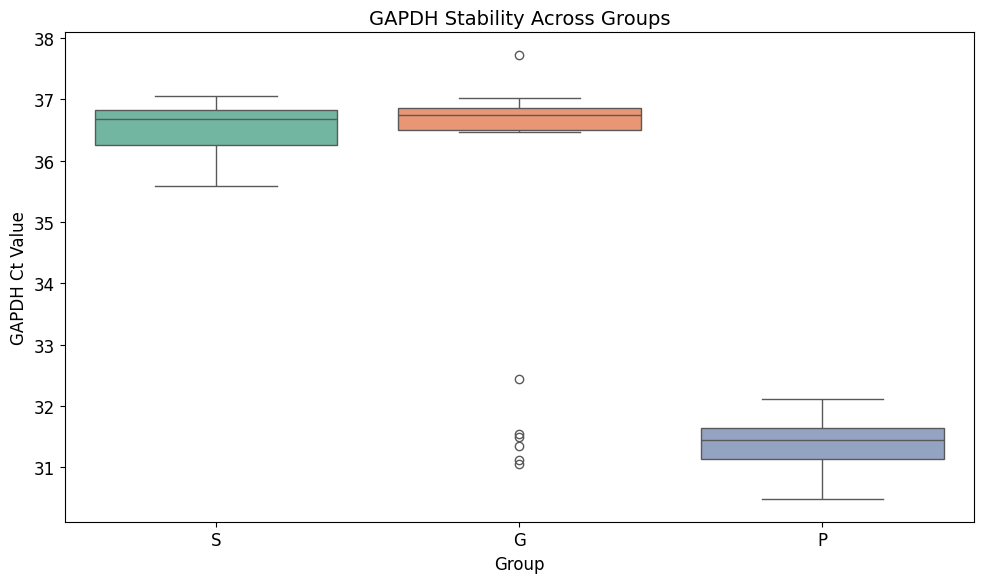


🔍 GAPDH vs Clinical Variables Correlations:
  plaque_index: r=-0.661, p=0.000
  gingival_index: r=-0.605, p=0.000
  pocket_depth: r=-0.814, p=0.000
  bleeding_on_probing: r=-0.755, p=0.000
  number_of_missing_teeth: r=-0.238, p=0.013
📊 GAPDH analysis saved to: outputs/jupyter_notebook/tables\GAPDH_Clinical_Correlations.csv
📋 Reference gene limitation report saved


In [5]:
# Reference Gene Validation (GAPDH Stability)
print("🔬 REFERENCE GENE VALIDATION")
print("=" * 50)

# Test GAPDH stability across groups
gapdh_by_group = df.groupby("GROUP")["mean_GAPDH"].agg(["mean", "std", "count"])
print("GAPDH stability by group:")
print(gapdh_by_group)

# Statistical test for GAPDH stability
groups = [
    df[df["GROUP"] == group]["mean_GAPDH"].values for group in ANALYSIS_CONFIG["groups"]
]
kruskal_stat, kruskal_p = kruskal(*groups)
print(f"\nKruskal-Wallis test for GAPDH stability:")
print(f"H-statistic: {kruskal_stat:.3f}")
print(f"p-value: {kruskal_p:.3f}")

if kruskal_p < 0.05:
    print("⚠️  GAPDH shows significant variation across groups - proceed with caution!")
else:
    print("✅ GAPDH is stable across groups")

# Create GAPDH stability plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="GROUP", y="mean_GAPDH", palette="Set2")
plt.title("GAPDH Stability Across Groups")
plt.ylabel("GAPDH Ct Value")
plt.xlabel("Group")
plt.tight_layout()
plt.savefig(
    get_output_path("GAPDH_Stability_Boxplot.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# Calculate correlations between GAPDH and clinical variables
print("\n🔍 GAPDH vs Clinical Variables Correlations:")
gapdh_correlations = []
for clinical_var in ANALYSIS_CONFIG["clinical_vars"]:
    if clinical_var in df.columns:
        corr, p_val = pearsonr(df["mean_GAPDH"], df[clinical_var])
        gapdh_correlations.append(
            {"Clinical_Variable": clinical_var, "Correlation": corr, "P_Value": p_val}
        )
        print(f"  {clinical_var}: r={corr:.3f}, p={p_val:.3f}")

# Save GAPDH correlations
gapdh_corr_df = pd.DataFrame(gapdh_correlations)
gapdh_corr_df.to_csv(
    get_output_path("GAPDH_Clinical_Correlations.csv", "tables"), index=False
)

print(
    f"📊 GAPDH analysis saved to: {get_output_path('GAPDH_Clinical_Correlations.csv', 'tables')}"
)

# Document reference gene limitation
limitation_report = f"""
REFERENCE GENE LIMITATION REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

Single Reference Gene Analysis:
- Reference gene: GAPDH
- Stability across groups: {'STABLE' if kruskal_p >= 0.05 else 'UNSTABLE'}
- Kruskal-Wallis p-value: {kruskal_p:.6f}

Limitations:
1. Single reference gene may not capture all sources of technical variation
2. Multiple reference genes are recommended for robust normalization
3. Results should be interpreted considering potential reference gene bias
4. Future validation with additional reference genes is recommended

Recommendation: Consider validating key findings with alternative reference genes
"""

with open(get_output_path("Reference_Gene_Limitation_Report.txt", "tables"), "w") as f:
    f.write(limitation_report)

print("📋 Reference gene limitation report saved")


# 3. Exploratory Data Analysis

Comprehensive exploratory analysis including descriptive statistics, correlations, and initial visualizations.

👥 DEMOGRAPHIC AND CLINICAL STATISTICS


📊 Demographic and Clinical Statistics by Group:
  Group   N  Age_Mean  Age_Std  Sex_M_Count  Sex_F_Count  Sex_M_Percent  \
0     S  36    24.306    3.702           17           19         47.222   
1     G  36    22.444    1.698           16           20         44.444   
2     P  36    30.278    5.785           18           18         50.000   

   plaque_index_Mean  plaque_index_Std  gingival_index_Mean  \
0              0.441             0.241                0.501   
1              1.075             0.539                1.212   
2              1.739             0.512                1.672   

   gingival_index_Std  pocket_depth_Mean  pocket_depth_Std  \
0               0.238              1.977             0.207   
1               0.404              2.211             0.317   
2               0.406              3.919             0.685   

   bleeding_on_probing_Mean  bleeding_on_probing_Std  \
0                     5.782                    3.067   
1                    25.012         

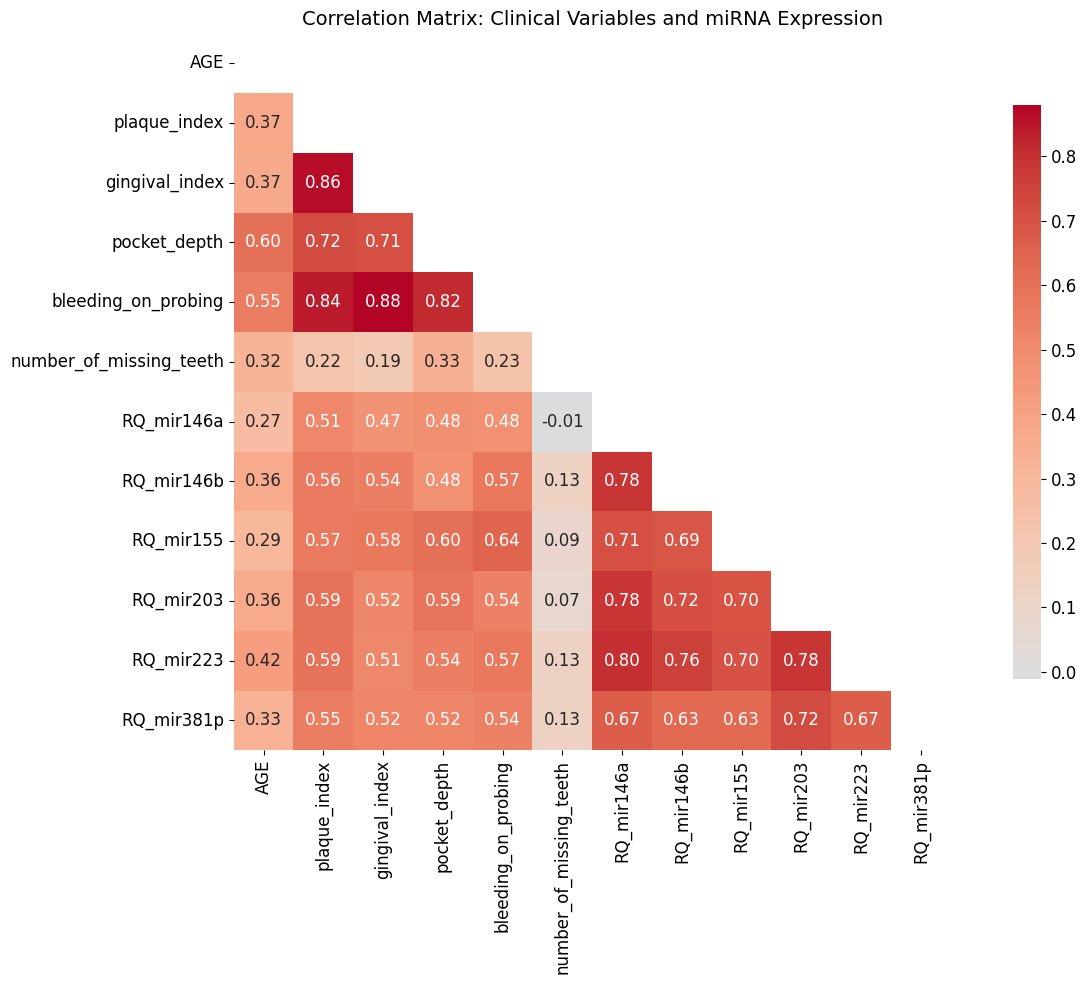


🔍 Significant Correlations (|r| > 0.3):
  gingival_index ↔ bleeding_on_probing: r=0.879
  plaque_index ↔ gingival_index: r=0.860
  plaque_index ↔ bleeding_on_probing: r=0.843
  pocket_depth ↔ bleeding_on_probing: r=0.816
  RQ_mir146a ↔ RQ_mir223: r=0.799
  RQ_mir146a ↔ RQ_mir146b: r=0.784
  RQ_mir146a ↔ RQ_mir203: r=0.783
  RQ_mir203 ↔ RQ_mir223: r=0.783
  RQ_mir146b ↔ RQ_mir223: r=0.760
  RQ_mir203 ↔ RQ_mir381p: r=0.721

📊 Full correlation matrix saved to: outputs/jupyter_notebook/tables\Overall_Correlations.csv


In [6]:
# Demographic and Clinical Statistics
print("👥 DEMOGRAPHIC AND CLINICAL STATISTICS")
print("=" * 50)

# Group-wise statistics
demographic_stats = []

for group in ANALYSIS_CONFIG["groups"]:
    group_data = df[df["GROUP"] == group]

    # Basic demographics
    stats_row = {
        "Group": group,
        "N": len(group_data),
        "Age_Mean": group_data["AGE"].mean(),
        "Age_Std": group_data["AGE"].std(),
        "Sex_M_Count": (group_data["SEX"] == "M").sum(),
        "Sex_F_Count": (group_data["SEX"] == "F").sum(),
        "Sex_M_Percent": (group_data["SEX"] == "M").mean() * 100,
    }

    # Clinical variables
    for clinical_var in ANALYSIS_CONFIG["clinical_vars"]:
        if clinical_var in group_data.columns:
            stats_row[f"{clinical_var}_Mean"] = group_data[clinical_var].mean()
            stats_row[f"{clinical_var}_Std"] = group_data[clinical_var].std()

    demographic_stats.append(stats_row)

# Create demographic statistics table
demo_stats_df = pd.DataFrame(demographic_stats)
demo_stats_df.to_csv(
    get_output_path("Demographic_Clinical_Stats.csv", "tables"), index=False
)

print("📊 Demographic and Clinical Statistics by Group:")
print(demo_stats_df.round(3))

# Normality testing for continuous variables
print("\n🔬 NORMALITY TESTING")
print("=" * 50)

normality_results = []
continuous_vars = (
    ["AGE"]
    + ANALYSIS_CONFIG["clinical_vars"]
    + [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
)

for var in continuous_vars:
    if var in df.columns:
        # Shapiro-Wilk test
        stat, p_value = shapiro(df[var])
        normality_results.append(
            {
                "Variable": var,
                "Shapiro_Wilk_Stat": stat,
                "P_Value": p_value,
                "Is_Normal": p_value > 0.05,
            }
        )

        print(
            f"{var}: W={stat:.3f}, p={p_value:.3f} {'(Normal)' if p_value > 0.05 else '(Non-normal)'}"
        )

# Save normality test results
normality_df = pd.DataFrame(normality_results)
normality_df.to_csv(
    get_output_path("Normality_Test_Results.csv", "tables"), index=False
)

print(
    f"\n📊 Normality test results saved to: {get_output_path('Normality_Test_Results.csv', 'tables')}"
)

# Overall correlation analysis
print("\n🔗 CORRELATION ANALYSIS")
print("=" * 50)

# Select numeric columns for correlation
numeric_cols = (
    ["AGE"]
    + ANALYSIS_CONFIG["clinical_vars"]
    + [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
)
numeric_data = df[numeric_cols].select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix: Clinical Variables and miRNA Expression")
plt.tight_layout()
plt.savefig(get_output_path("Correlation_Heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save correlation matrix
correlation_matrix.to_csv(get_output_path("Overall_Correlations.csv", "tables"))

# Identify significant correlations
significant_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        var1 = correlation_matrix.columns[i]
        var2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.3:  # Threshold for reporting
            significant_correlations.append(
                {
                    "Variable_1": var1,
                    "Variable_2": var2,
                    "Correlation": corr_value,
                    "Abs_Correlation": abs(corr_value),
                }
            )

# Sort by absolute correlation
significant_correlations.sort(key=lambda x: x["Abs_Correlation"], reverse=True)

print("\n🔍 Significant Correlations (|r| > 0.3):")
for corr in significant_correlations[:10]:  # Top 10
    print(f"  {corr['Variable_1']} ↔ {corr['Variable_2']}: r={corr['Correlation']:.3f}")

print(
    f"\n📊 Full correlation matrix saved to: {get_output_path('Overall_Correlations.csv', 'tables')}"
)


📊 RQ DISTRIBUTION ANALYSIS


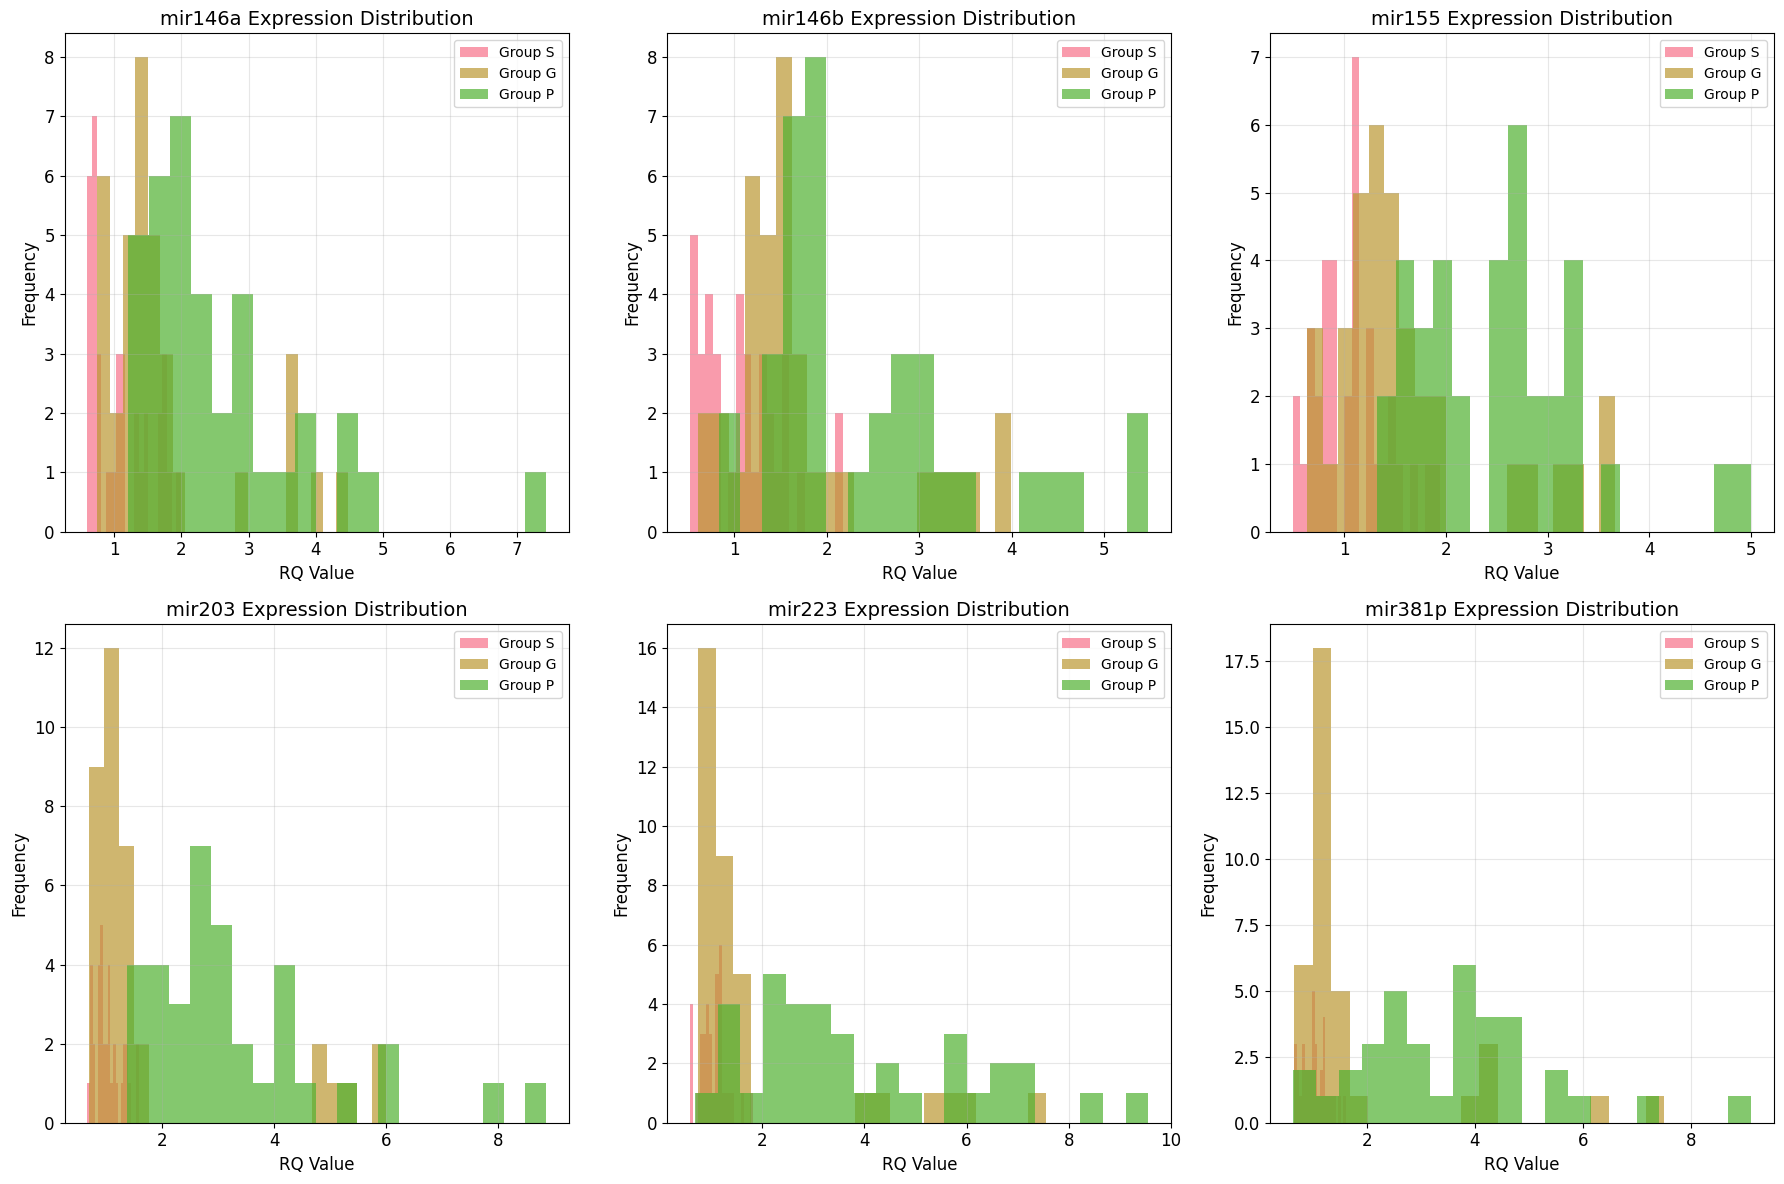


📊 RQ VALUE SUMMARY STATISTICS
RQ summary by group:
      RQ_mir146a                             RQ_mir146b                       \
            mean    std median    min    max       mean    std median    min   
GROUP                                                                          
G          1.727  0.986  1.458  0.750  4.486      1.735  0.889  1.501  0.603   
P          2.548  1.260  2.137  1.205  7.423      2.452  1.162  1.965  0.830   
S          1.078  0.431  1.014  0.601  1.993      1.080  0.432  1.062  0.522   

             RQ_mir155                             RQ_mir203                \
         max      mean    std median    min    max      mean    std median   
GROUP                                                                        
G      3.994     1.627  0.794  1.387  0.637  3.660     1.821  1.633  1.180   
P      5.481     2.535  0.840  2.579  1.321  4.999     3.353  1.691  2.919   
S      2.175     1.058  0.360  1.068  0.495  1.939     1.026  0.241  0.969   

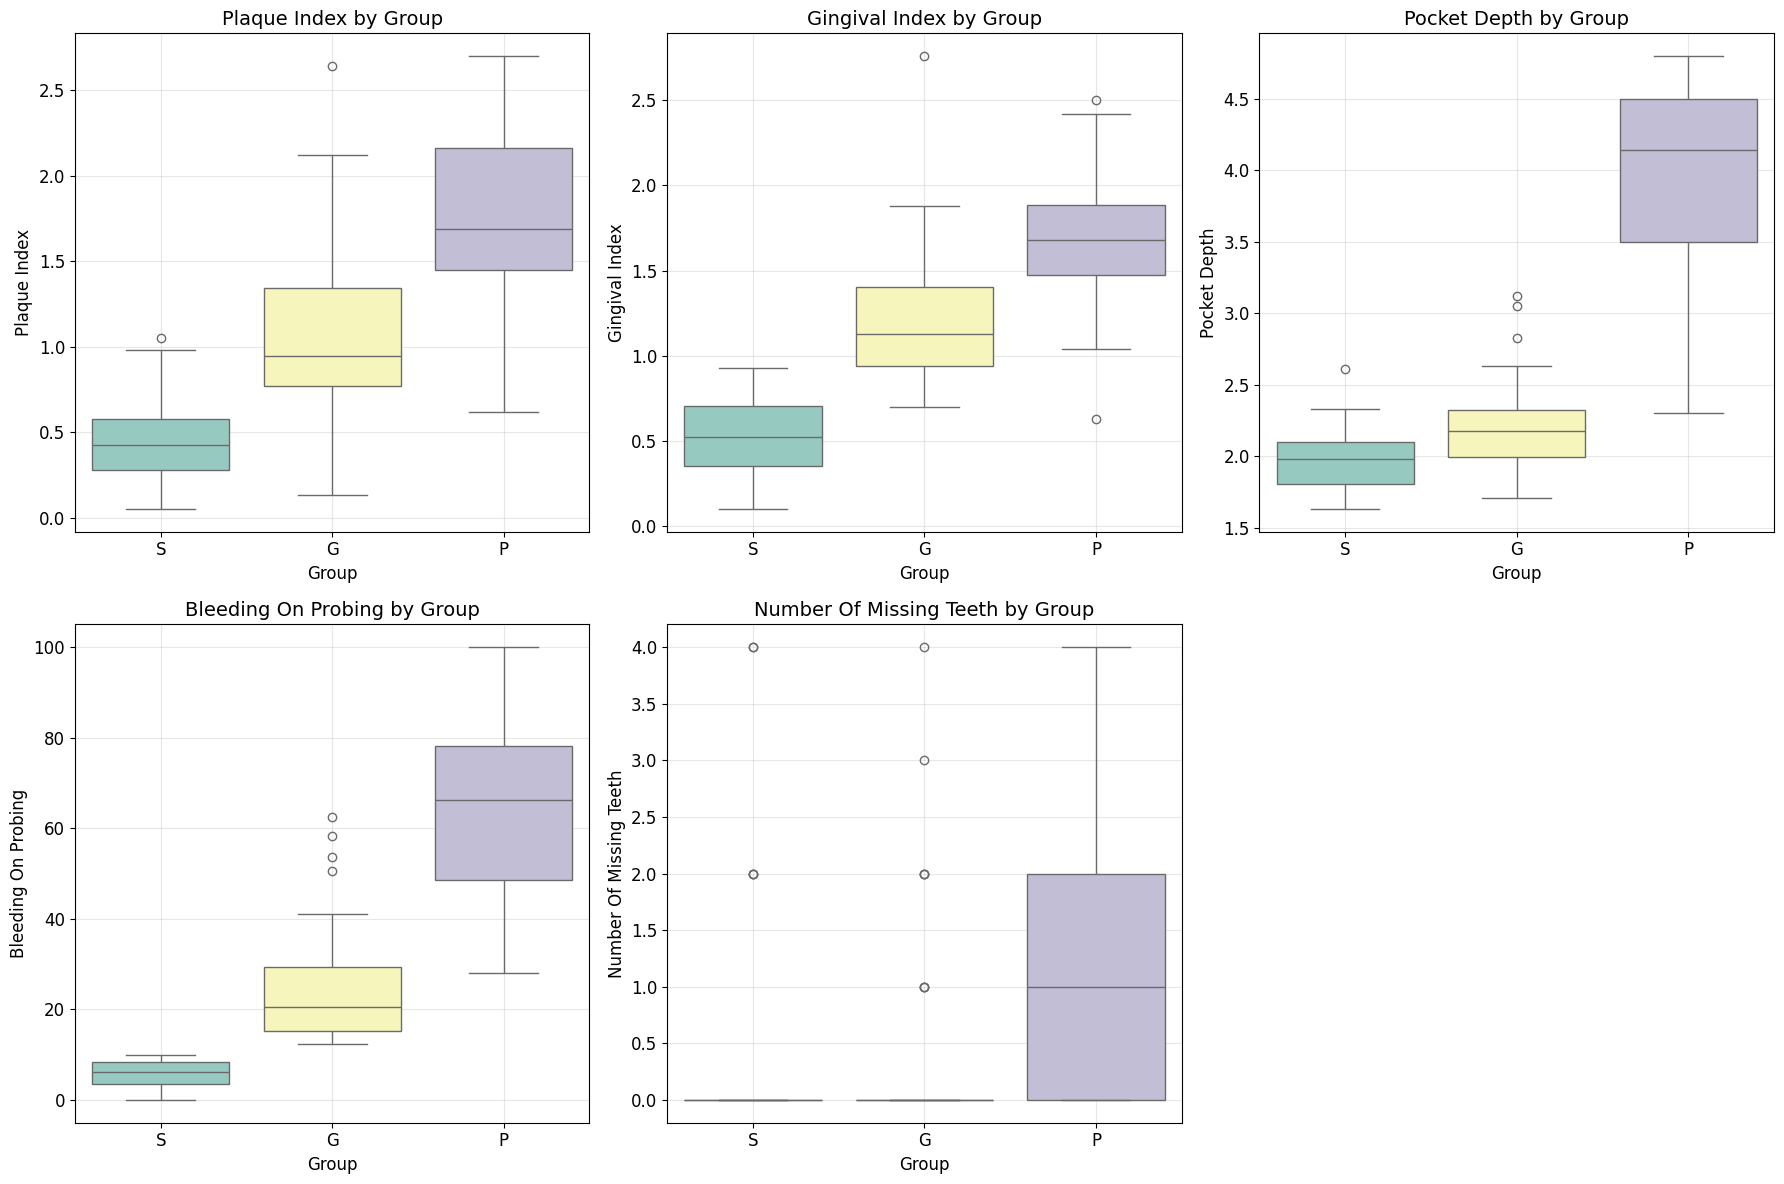

✅ Exploratory data analysis complete!
📊 55 significant correlations identified
📈 Distribution plots saved to: outputs/jupyter_notebook/plots\RQ_Distributions.png
📊 Clinical variables plot saved to: outputs/jupyter_notebook/plots\Clinical_Variables_By_Group.png


In [7]:
# RQ Distribution Analysis
print("📊 RQ DISTRIBUTION ANALYSIS")
print("=" * 50)

# Create RQ distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, mirna in enumerate(ANALYSIS_CONFIG["mirna_names"]):
    rq_col = f"RQ_{mirna}"

    # Distribution by group
    for group in ANALYSIS_CONFIG["groups"]:
        group_data = df[df["GROUP"] == group][rq_col]
        axes[i].hist(group_data, alpha=0.7, label=f"Group {group}", bins=20)

    axes[i].set_title(f"{mirna} Expression Distribution")
    axes[i].set_xlabel("RQ Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(get_output_path("RQ_Distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

# Summary statistics for RQ values
print("\n📊 RQ VALUE SUMMARY STATISTICS")
print("=" * 50)

rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
rq_summary = df.groupby("GROUP")[rq_cols].agg(["mean", "std", "median", "min", "max"])

print("RQ summary by group:")
print(rq_summary.round(3))

# Clinical variables by group visualization
print("\n📊 CLINICAL VARIABLES BY GROUP")
print("=" * 50)

# Create clinical variables plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, clinical_var in enumerate(ANALYSIS_CONFIG["clinical_vars"]):
    if clinical_var in df.columns and i < len(axes):
        sns.boxplot(data=df, x="GROUP", y=clinical_var, ax=axes[i], palette="Set3")
        axes[i].set_title(f'{clinical_var.replace("_", " ").title()} by Group')
        axes[i].set_xlabel("Group")
        axes[i].set_ylabel(clinical_var.replace("_", " ").title())
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(ANALYSIS_CONFIG["clinical_vars"]), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(
    get_output_path("Clinical_Variables_By_Group.png"), dpi=300, bbox_inches="tight"
)
plt.show()

print("✅ Exploratory data analysis complete!")
print(f"📊 {len(significant_correlations)} significant correlations identified")
print(f"📈 Distribution plots saved to: {get_output_path('RQ_Distributions.png')}")
print(
    f"📊 Clinical variables plot saved to: {get_output_path('Clinical_Variables_By_Group.png')}"
)


# 4. Statistical Analysis

Comprehensive statistical analysis with omnibus testing, pairwise comparisons, FDR correction, and effect size calculations.

In [8]:
# Statistical Analysis Functions
def calculate_effect_size(group1, group2):
    """Calculate Cohen's d effect size"""
    mean1, mean2 = np.mean(group1), np.mean(group2)
    pooled_std = np.sqrt(
        ((np.std(group1, ddof=1) ** 2) + (np.std(group2, ddof=1) ** 2)) / 2
    )
    return (mean1 - mean2) / pooled_std if pooled_std > 0 else 0


def perform_omnibus_test(data, groups, variable):
    """Perform omnibus test (Kruskal-Wallis)"""
    group_data = [data[data["GROUP"] == group][variable].dropna() for group in groups]

    # Remove empty groups
    group_data = [group for group in group_data if len(group) > 0]

    if len(group_data) < 2:
        return None, None, None

    try:
        stat, p_value = kruskal(*group_data)
        return stat, p_value, len(group_data)
    except:
        return None, None, None


def perform_pairwise_comparison(data, var, group1, group2):
    """Perform pairwise comparison between two groups"""
    data1 = data[data["GROUP"] == group1][var].dropna()
    data2 = data[data["GROUP"] == group2][var].dropna()

    if len(data1) == 0 or len(data2) == 0:
        return None, None, None, None, None

    # Mann-Whitney U test (non-parametric)
    try:
        stat, p_value = mannwhitneyu(data1, data2, alternative="two-sided")
        effect_size = calculate_effect_size(data1, data2)
        log2_fc = (
            np.log2(np.median(data1) / np.median(data2)) if np.median(data2) > 0 else 0
        )
        median_diff = np.median(data1) - np.median(data2)

        return stat, p_value, effect_size, log2_fc, median_diff
    except:
        return None, None, None, None, None


# Omnibus Testing
print("🔬 OMNIBUS TESTING (Kruskal-Wallis)")
print("=" * 50)

omnibus_results = []
rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]

for variable in rq_cols:
    stat, p_value, n_groups = perform_omnibus_test(
        df, ANALYSIS_CONFIG["groups"], variable
    )

    if stat is not None:
        omnibus_results.append(
            {
                "Variable": variable,
                "Kruskal_Wallis_Stat": stat,
                "P_Value": p_value,
                "N_Groups": n_groups,
                "Significant": p_value < ANALYSIS_CONFIG["alpha_level"],
            }
        )

        print(
            f"{variable}: H={stat:.3f}, p={p_value:.3f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''}"
        )

# Apply FDR correction
omnibus_df = pd.DataFrame(omnibus_results)
if len(omnibus_df) > 0:
    _, omnibus_df["Q_Value"], _, _ = smt.multipletests(
        omnibus_df["P_Value"], method=ANALYSIS_CONFIG["fdr_method"]
    )
    omnibus_df["FDR_Significant"] = (
        omnibus_df["Q_Value"] < ANALYSIS_CONFIG["alpha_level"]
    )

omnibus_df.to_csv(get_output_path("Omnibus_Test_Results.csv", "tables"), index=False)

print(
    f"\n📊 Omnibus test results saved to: {get_output_path('Omnibus_Test_Results.csv', 'tables')}"
)
print(
    f"🔍 {sum(omnibus_df['FDR_Significant'])} miRNAs show significant omnibus effects (FDR < 0.05)"
)

# Display significant omnibus results
significant_omnibus = omnibus_df[omnibus_df["FDR_Significant"]]
if len(significant_omnibus) > 0:
    print("\n✅ Significant omnibus effects (FDR corrected):")
    print(
        significant_omnibus[
            ["Variable", "Kruskal_Wallis_Stat", "P_Value", "Q_Value"]
        ].round(4)
    )


🔬 OMNIBUS TESTING (Kruskal-Wallis)
RQ_mir146a: H=45.605, p=0.000 ***
RQ_mir146b: H=43.219, p=0.000 ***
RQ_mir155: H=55.644, p=0.000 ***
RQ_mir203: H=56.521, p=0.000 ***
RQ_mir223: H=49.477, p=0.000 ***
RQ_mir381p: H=49.742, p=0.000 ***

📊 Omnibus test results saved to: outputs/jupyter_notebook/tables\Omnibus_Test_Results.csv
🔍 6 miRNAs show significant omnibus effects (FDR < 0.05)

✅ Significant omnibus effects (FDR corrected):
     Variable  Kruskal_Wallis_Stat  P_Value  Q_Value
0  RQ_mir146a              45.6047      0.0      0.0
1  RQ_mir146b              43.2186      0.0      0.0
2   RQ_mir155              55.6445      0.0      0.0
3   RQ_mir203              56.5208      0.0      0.0
4   RQ_mir223              49.4771      0.0      0.0
5  RQ_mir381p              49.7420      0.0      0.0
RQ_mir146a: H=45.605, p=0.000 ***
RQ_mir146b: H=43.219, p=0.000 ***
RQ_mir155: H=55.644, p=0.000 ***
RQ_mir203: H=56.521, p=0.000 ***
RQ_mir223: H=49.477, p=0.000 ***
RQ_mir381p: H=49.742, p=0.000 

In [9]:
# Pairwise Comparisons
print("\n🔬 PAIRWISE COMPARISONS")
print("=" * 50)

# Define comparison pairs
comparison_pairs = [
    ("S", "P", "H_vs_P"),  # Healthy vs Periodontitis
    ("S", "G", "H_vs_G"),  # Healthy vs Gingivitis
    ("G", "P", "G_vs_P"),  # Gingivitis vs Periodontitis
]

# Store all pairwise results
all_pairwise_results = {}

for group1, group2, comparison_name in comparison_pairs:
    print(f"\n📊 {comparison_name.replace('_', ' ')} Comparison:")
    print("-" * 30)

    pairwise_results = []

    for variable in rq_cols:
        stat, p_value, effect_size, log2_fc, median_diff = perform_pairwise_comparison(
            df, variable, group1, group2
        )

        if stat is not None:
            pairwise_results.append(
                {
                    "miRNA": variable.replace("RQ_", ""),
                    "Group1": group1,
                    "Group2": group2,
                    "Comparison": comparison_name,
                    "Mann_Whitney_U": stat,
                    "P_Value": p_value,
                    "Log2_FC": log2_fc,
                    "Effect_Size": effect_size,
                    "Median_Diff": median_diff,
                }
            )

            print(
                f"  {variable}: U={stat:.1f}, p={p_value:.3f}, log2FC={log2_fc:.3f}, d={effect_size:.3f}"
            )

    # Create DataFrame and apply FDR correction
    pairwise_df = pd.DataFrame(pairwise_results)
    if len(pairwise_df) > 0:
        _, pairwise_df["Q_Value"], _, _ = smt.multipletests(
            pairwise_df["P_Value"], method=ANALYSIS_CONFIG["fdr_method"]
        )
        pairwise_df["FDR_Significant"] = (
            pairwise_df["Q_Value"] < ANALYSIS_CONFIG["alpha_level"]
        )
        pairwise_df["Effect_Size_Large"] = np.abs(pairwise_df["Effect_Size"]) > 0.8
        pairwise_df["Log2FC_Threshold"] = (
            np.abs(pairwise_df["Log2_FC"]) > ANALYSIS_CONFIG["effect_size_threshold"]
        )

        # Save results
        output_filename = f"{comparison_name}_Results.csv"
        pairwise_df.to_csv(get_output_path(output_filename, "tables"), index=False)
        all_pairwise_results[comparison_name] = pairwise_df

        # Identify candidate biomarkers
        candidates = pairwise_df[
            (pairwise_df["FDR_Significant"]) & (pairwise_df["Log2FC_Threshold"])
        ]

        if len(candidates) > 0:
            print(
                f"  ✅ {len(candidates)} candidate biomarkers identified (FDR < 0.05, |log2FC| > 1)"
            )
            candidate_filename = f"Candidate_Biomarkers_{comparison_name}.csv"
            candidates.to_csv(
                get_output_path(candidate_filename, "tables"), index=False
            )

            # Display top candidates
            candidates_sorted = candidates.sort_values("Q_Value")
            print("  Top candidates:")
            for _, row in candidates_sorted.head(3).iterrows():
                print(
                    f"    {row['miRNA']}: q={row['Q_Value']:.3f}, log2FC={row['Log2_FC']:.3f}"
                )
        else:
            print(f"  ❌ No candidate biomarkers identified")

        print(f"  📊 Results saved to: {get_output_path(output_filename, 'tables')}")

print(f"\n✅ Pairwise comparisons complete!")
print(f"📊 {len(all_pairwise_results)} comparison sets analyzed")



🔬 PAIRWISE COMPARISONS

📊 H vs P Comparison:
------------------------------
  RQ_mir146a: U=87.0, p=0.000, log2FC=-1.075, d=-1.562
  RQ_mir146b: U=103.0, p=0.000, log2FC=-0.888, d=-1.566
  RQ_mir155: U=33.0, p=0.000, log2FC=-1.272, d=-2.286
  RQ_mir203: U=5.0, p=0.000, log2FC=-1.590, d=-1.926
  RQ_mir223: U=50.0, p=0.000, log2FC=-1.611, d=-1.827
  RQ_mir381p: U=72.0, p=0.000, log2FC=-1.890, d=-2.044
  ✅ 5 candidate biomarkers identified (FDR < 0.05, |log2FC| > 1)
  Top candidates:
    mir203: q=0.000, log2FC=-1.590
    mir155: q=0.000, log2FC=-1.272
    mir223: q=0.000, log2FC=-1.611
  📊 Results saved to: outputs/jupyter_notebook/tables\H_vs_P_Results.csv

📊 H vs G Comparison:
------------------------------
  RQ_mir146a: U=331.5, p=0.000, log2FC=-0.523, d=-0.853
  RQ_mir146b: U=306.0, p=0.000, log2FC=-0.500, d=-0.937
  RQ_mir155: U=317.0, p=0.000, log2FC=-0.377, d=-0.924
  RQ_mir203: U=421.0, p=0.011, log2FC=-0.283, d=-0.682
  RQ_mir223: U=449.5, p=0.026, log2FC=-0.105, d=-0.655
  RQ_


🌋 VOLCANO PLOTS


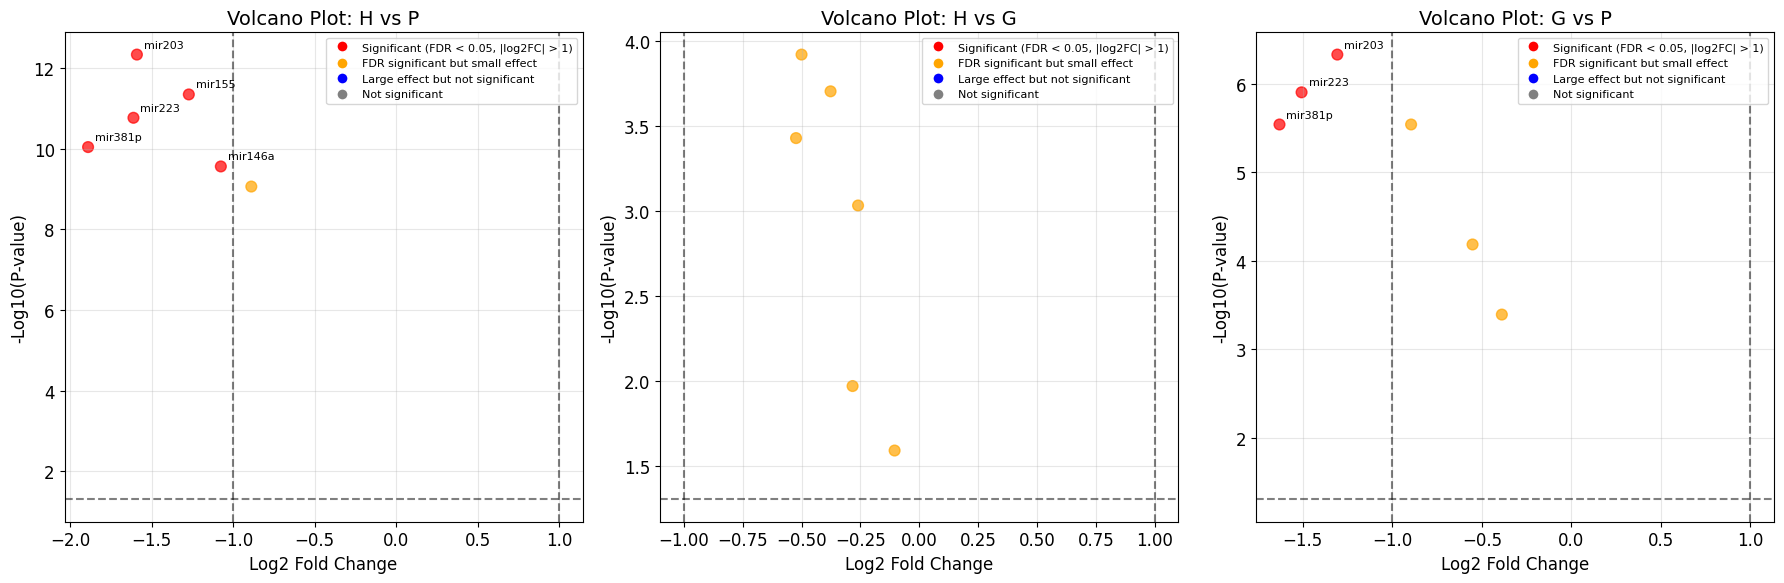


📊 DIFFERENTIAL EXPRESSION SUMMARY
✅ 8 significant differential expression results identified
📊 Results saved to: outputs/jupyter_notebook/tables\All_Significant_Results.csv

🔍 Summary by miRNA:
  mir146a: 1 significant comparison(s)
    H_vs_P: log2FC=-1.075, q=0.000
  mir155: 1 significant comparison(s)
    H_vs_P: log2FC=-1.272, q=0.000
  mir203: 2 significant comparison(s)
    H_vs_P: log2FC=-1.590, q=0.000
    G_vs_P: log2FC=-1.307, q=0.000
  mir223: 2 significant comparison(s)
    H_vs_P: log2FC=-1.611, q=0.000
    G_vs_P: log2FC=-1.507, q=0.000
  mir381p: 2 significant comparison(s)
    H_vs_P: log2FC=-1.890, q=0.000
    G_vs_P: log2FC=-1.630, q=0.000

📊 Volcano plots saved to: outputs/jupyter_notebook/plots\Volcano_Plots.png


In [10]:
# Volcano Plots for Differential Expression
print("\n🌋 VOLCANO PLOTS")
print("=" * 50)

# Create volcano plots for each comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (comparison_name, results_df) in enumerate(all_pairwise_results.items()):
    ax = axes[i]

    # Calculate -log10(p-value)
    results_df["neg_log10_p"] = -np.log10(results_df["P_Value"])

    # Define significance thresholds
    p_threshold = -np.log10(ANALYSIS_CONFIG["alpha_level"])
    fc_threshold = ANALYSIS_CONFIG["effect_size_threshold"]

    # Color points based on significance
    colors = []
    for _, row in results_df.iterrows():
        if row["FDR_Significant"] and abs(row["Log2_FC"]) > fc_threshold:
            colors.append("red")  # Significant
        elif row["FDR_Significant"]:
            colors.append("orange")  # FDR significant but small effect
        elif abs(row["Log2_FC"]) > fc_threshold:
            colors.append("blue")  # Large effect but not significant
        else:
            colors.append("gray")  # Not significant

    # Create scatter plot
    scatter = ax.scatter(
        results_df["Log2_FC"], results_df["neg_log10_p"], c=colors, alpha=0.7, s=60
    )

    # Add threshold lines
    ax.axhline(y=p_threshold, color="black", linestyle="--", alpha=0.5)
    ax.axvline(x=fc_threshold, color="black", linestyle="--", alpha=0.5)
    ax.axvline(x=-fc_threshold, color="black", linestyle="--", alpha=0.5)

    # Annotate significant points
    for _, row in results_df.iterrows():
        if row["FDR_Significant"] and abs(row["Log2_FC"]) > fc_threshold:
            ax.annotate(
                row["miRNA"],
                (row["Log2_FC"], row["neg_log10_p"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    # Formatting
    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-Log10(P-value)")
    ax.set_title(f'Volcano Plot: {comparison_name.replace("_", " ")}')
    ax.grid(True, alpha=0.3)

    # Add legend
    legend_elements = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="red",
            markersize=8,
            label="Significant (FDR < 0.05, |log2FC| > 1)",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="orange",
            markersize=8,
            label="FDR significant but small effect",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="blue",
            markersize=8,
            label="Large effect but not significant",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="gray",
            markersize=8,
            label="Not significant",
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(get_output_path("Volcano_Plots.png"), dpi=300, bbox_inches="tight")
plt.show()

# Create summary of all significant results
print("\n📊 DIFFERENTIAL EXPRESSION SUMMARY")
print("=" * 50)

all_significant = []
for comparison_name, results_df in all_pairwise_results.items():
    significant_results = results_df[
        (results_df["FDR_Significant"]) & (results_df["Log2FC_Threshold"])
    ]

    for _, row in significant_results.iterrows():
        all_significant.append(
            {
                "miRNA": row["miRNA"],
                "Comparison": comparison_name,
                "Log2_FC": row["Log2_FC"],
                "P_Value": row["P_Value"],
                "Q_Value": row["Q_Value"],
                "Effect_Size": row["Effect_Size"],
            }
        )

if all_significant:
    significant_df = pd.DataFrame(all_significant)
    significant_df = significant_df.sort_values(["miRNA", "Q_Value"])

    # Save comprehensive significant results
    significant_df.to_csv(
        get_output_path("All_Significant_Results.csv", "tables"), index=False
    )

    print(
        f"✅ {len(all_significant)} significant differential expression results identified"
    )
    print(
        f"📊 Results saved to: {get_output_path('All_Significant_Results.csv', 'tables')}"
    )

    # Display summary by miRNA
    print("\n🔍 Summary by miRNA:")
    for mirna in significant_df["miRNA"].unique():
        mirna_results = significant_df[significant_df["miRNA"] == mirna]
        print(f"  {mirna}: {len(mirna_results)} significant comparison(s)")
        for _, row in mirna_results.iterrows():
            print(
                f"    {row['Comparison']}: log2FC={row['Log2_FC']:.3f}, q={row['Q_Value']:.3f}"
            )
else:
    print("❌ No significant differential expression results identified")

print(f"\n📊 Volcano plots saved to: {get_output_path('Volcano_Plots.png')}")


# 5. Machine Learning Models

Predictive modeling using logistic regression and random forest classifiers with cross-validation and performance evaluation.

In [11]:
# Machine Learning Classification Models
print("🤖 MACHINE LEARNING MODELS")
print("=" * 50)

# Prepare data for machine learning
rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
feature_columns = rq_cols + ANALYSIS_CONFIG["clinical_vars"]

# Remove any columns that don't exist in the dataset
available_features = [col for col in feature_columns if col in df.columns]
X = df[available_features]

print(f"📊 Features selected: {len(available_features)}")
print(f"Features: {available_features}")

# Store all model results
all_model_results = []

# Binary classification problems
binary_problems = [
    ("S", "P", "Healthy_vs_Periodontitis"),
    ("S", "G", "Healthy_vs_Gingivitis"),
    ("G", "P", "Gingivitis_vs_Periodontitis"),
]

for group1, group2, problem_name in binary_problems:
    print(f"\n🎯 {problem_name.replace('_', ' ')} Classification:")
    print("-" * 40)

    # Filter data for binary classification
    binary_data = df[df["GROUP"].isin([group1, group2])].copy()
    X_binary = binary_data[available_features]
    y_binary = binary_data["GROUP"]

    # Encode labels
    label_map = {group1: 0, group2: 1}
    y_binary_encoded = y_binary.map(label_map)

    print(
        f"  Sample sizes: {group1}={sum(y_binary_encoded == 0)}, {group2}={sum(y_binary_encoded == 1)}"
    )

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_binary,
        y_binary_encoded,
        test_size=ANALYSIS_CONFIG["test_size"],
        random_state=ANALYSIS_CONFIG["random_state"],
        stratify=y_binary_encoded,
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Models to evaluate
    models = {
        "Logistic_Regression": LogisticRegression(
            random_state=ANALYSIS_CONFIG["random_state"]
        ),
        "Random_Forest": RandomForestClassifier(
            random_state=ANALYSIS_CONFIG["random_state"], n_estimators=100
        ),
    }

    problem_results = []

    for model_name, model in models.items():
        print(f"\n  🔮 {model_name.replace('_', ' ')} Model:")

        # Fit model
        if model_name == "Logistic_Regression":
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        # Cross-validation
        cv_scores = cross_val_score(
            model,
            X_train_scaled if model_name == "Logistic_Regression" else X_train,
            y_train,
            cv=ANALYSIS_CONFIG["cv_folds"],
            scoring="roc_auc",
        )

        # Store results
        result = {
            "Problem": problem_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "AUC": auc,
            "CV_Mean_AUC": cv_scores.mean(),
            "CV_Std_AUC": cv_scores.std(),
            "N_Train": len(X_train),
            "N_Test": len(X_test),
        }

        problem_results.append(result)
        all_model_results.append(result)

        print(f"    Accuracy: {accuracy:.3f}")
        print(f"    AUC: {auc:.3f}")
        print(f"    CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

        # Feature importance
        if model_name == "Random_Forest":
            feature_importance = model.feature_importances_
            feature_names = available_features

            # Create feature importance DataFrame
            importance_df = pd.DataFrame(
                {
                    "Feature": feature_names,
                    "Importance": feature_importance,
                    "Problem": problem_name,
                }
            ).sort_values("Importance", ascending=False)

            print(f"    Top 3 features:")
            for _, row in importance_df.head(3).iterrows():
                print(f"      {row['Feature']}: {row['Importance']:.3f}")

            # Save feature importance
            importance_filename = f"Feature_Importance_{problem_name}.csv"
            importance_df.to_csv(
                get_output_path(importance_filename, "tables"), index=False
            )

    print(f"  ✅ {problem_name} classification complete")

# Save all model results
model_results_df = pd.DataFrame(all_model_results)
model_results_df.to_csv(
    get_output_path("Model_Performance_Metrics.csv", "tables"), index=False
)

print(f"\n✅ Machine learning analysis complete!")
print(f"📊 {len(all_model_results)} model evaluations performed")
print(
    f"📊 Results saved to: {get_output_path('Model_Performance_Metrics.csv', 'tables')}"
)

# Display best performing models
print("\n🏆 BEST PERFORMING MODELS:")
print("=" * 50)
best_models = model_results_df.loc[model_results_df.groupby("Problem")["AUC"].idxmax()]
for _, row in best_models.iterrows():
    print(f"{row['Problem']}: {row['Model']} (AUC: {row['AUC']:.3f})")


🤖 MACHINE LEARNING MODELS
📊 Features selected: 11
Features: ['RQ_mir146a', 'RQ_mir146b', 'RQ_mir155', 'RQ_mir203', 'RQ_mir223', 'RQ_mir381p', 'plaque_index', 'gingival_index', 'pocket_depth', 'bleeding_on_probing', 'number_of_missing_teeth']

🎯 Healthy vs Periodontitis Classification:
----------------------------------------
  Sample sizes: S=36, P=36

  🔮 Logistic Regression Model:
    Accuracy: 1.000
    AUC: 1.000
    CV AUC: 1.000 ± 0.000

  🔮 Random Forest Model:
    Accuracy: 1.000
    AUC: 1.000
    CV AUC: 1.000 ± 0.000
    Top 3 features:
      bleeding_on_probing: 0.237
      gingival_index: 0.190
      RQ_mir203: 0.175
  ✅ Healthy_vs_Periodontitis classification complete

🎯 Healthy vs Gingivitis Classification:
----------------------------------------
  Sample sizes: S=36, G=36

  🔮 Logistic Regression Model:
    Accuracy: 1.000
    AUC: 1.000
    CV AUC: 0.981 ± 0.026

  🔮 Random Forest Model:
    Accuracy: 1.000
    AUC: 1.000
    CV AUC: 1.000 ± 0.000
    Top 3 features:



📊 ROC CURVES AND CONFUSION MATRICES


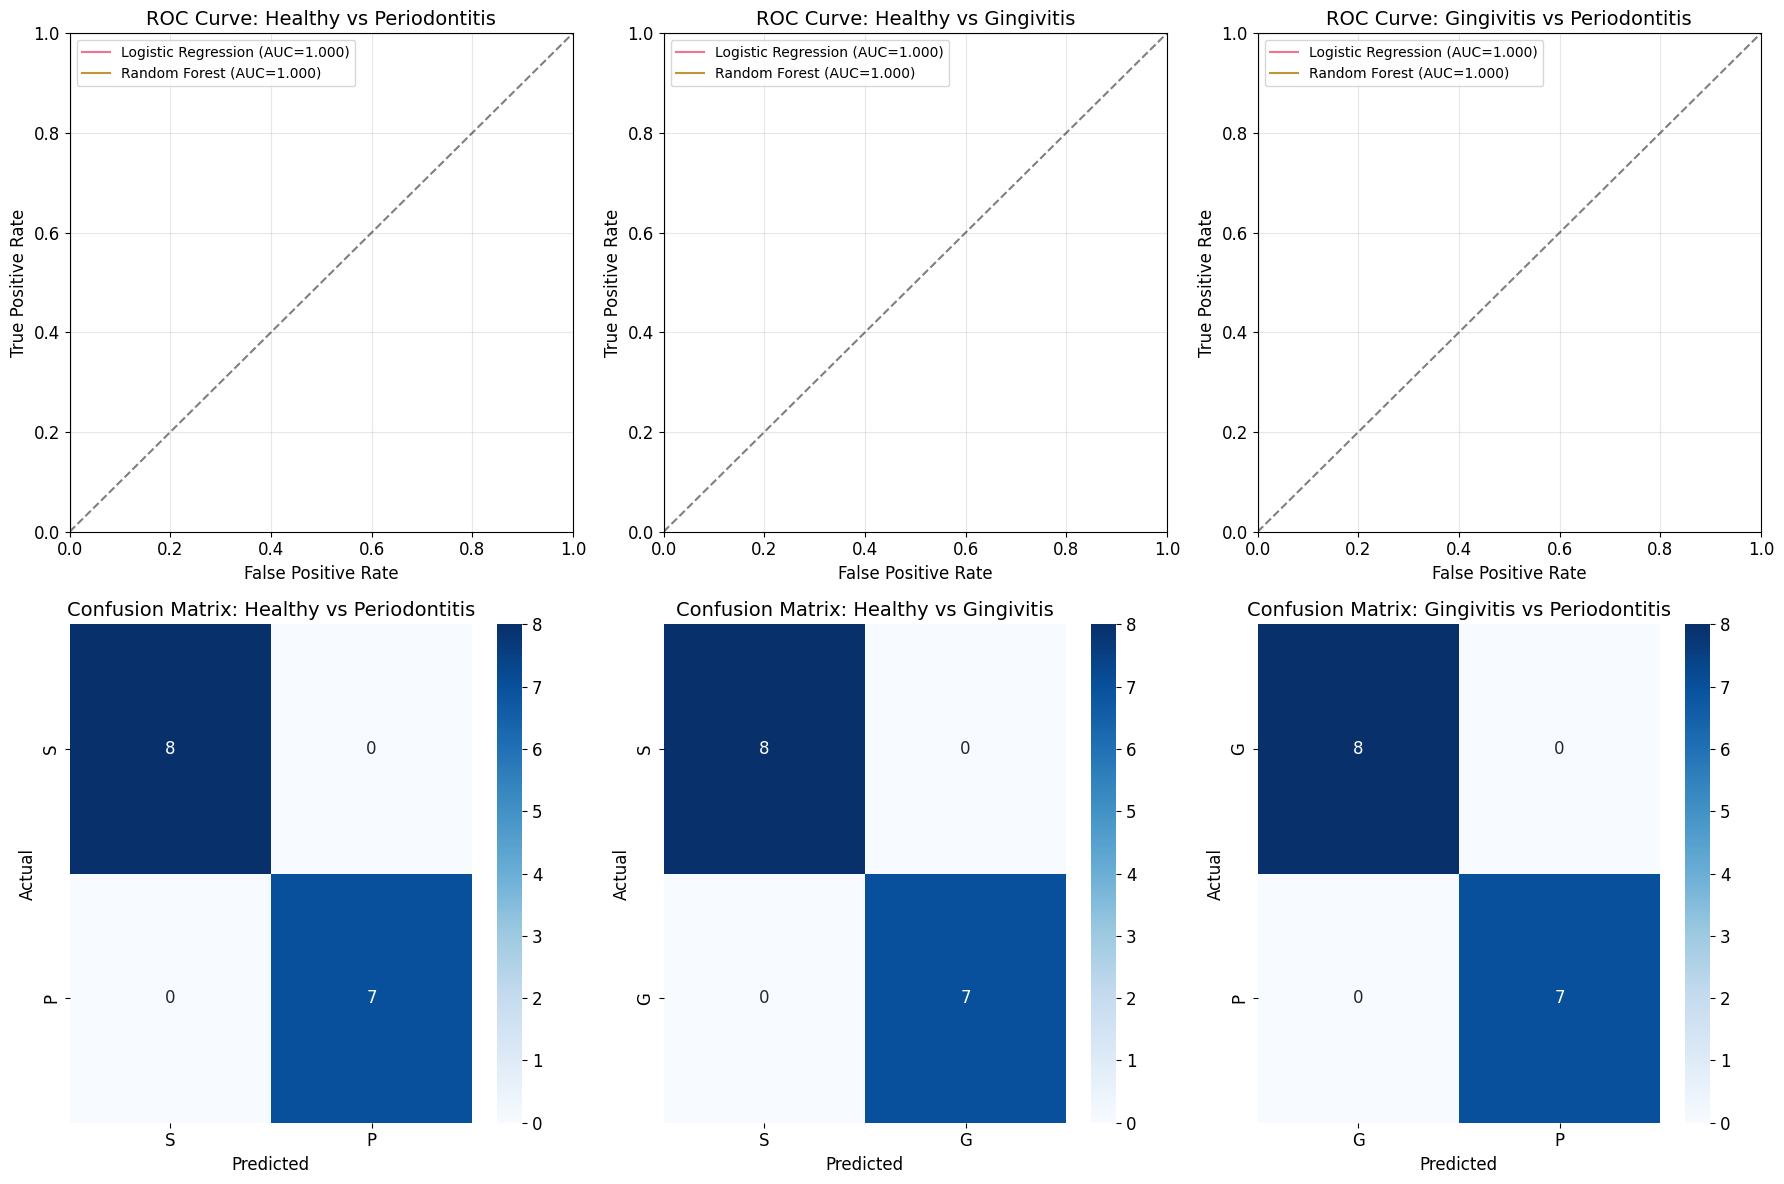

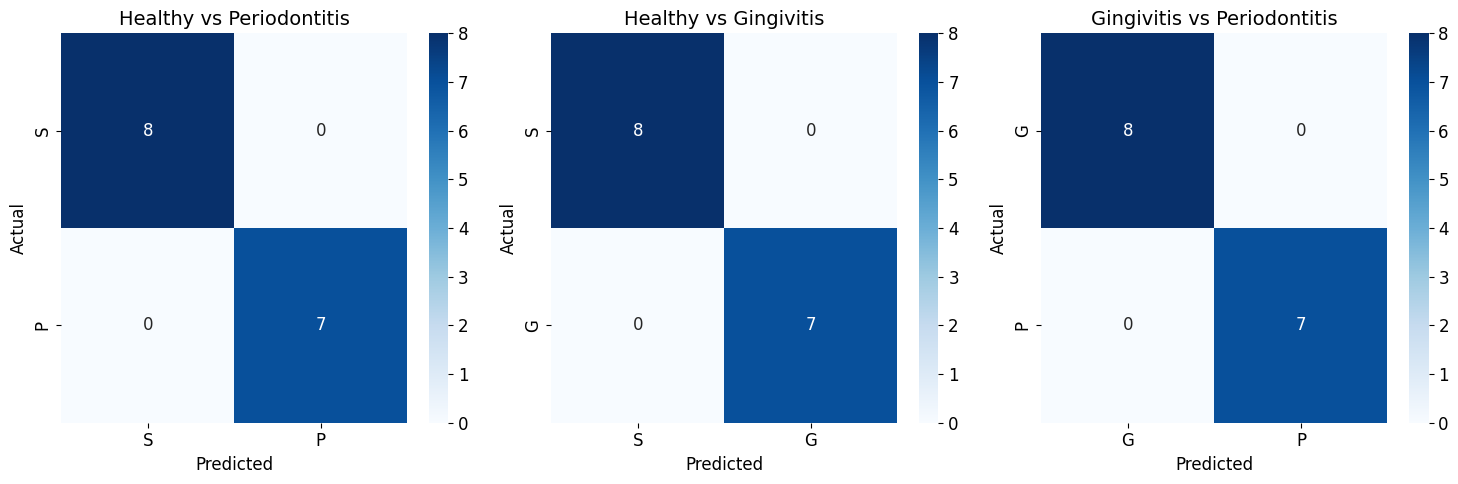

📊 ROC curves saved to: outputs/jupyter_notebook/plots\ROC_Curves.png
📊 Confusion matrices saved to: outputs/jupyter_notebook/plots\Confusion_Matrices.png


In [12]:
# ROC Curves and Confusion Matrices
print("\n📊 ROC CURVES AND CONFUSION MATRICES")
print("=" * 50)

# Create ROC curves for best models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0

for group1, group2, problem_name in binary_problems:
    # Prepare data again for visualization
    binary_data = df[df["GROUP"].isin([group1, group2])].copy()
    X_binary = binary_data[available_features]
    y_binary = binary_data["GROUP"]

    label_map = {group1: 0, group2: 1}
    y_binary_encoded = y_binary.map(label_map)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_binary,
        y_binary_encoded,
        test_size=ANALYSIS_CONFIG["test_size"],
        random_state=ANALYSIS_CONFIG["random_state"],
        stratify=y_binary_encoded,
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train both models
    models = {
        "Logistic Regression": LogisticRegression(
            random_state=ANALYSIS_CONFIG["random_state"]
        ),
        "Random Forest": RandomForestClassifier(
            random_state=ANALYSIS_CONFIG["random_state"], n_estimators=100
        ),
    }

    # ROC Curve
    ax_roc = axes[plot_idx]

    for model_name, model in models.items():
        if model_name == "Logistic Regression":
            model.fit(X_train_scaled, y_train)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)

        ax_roc.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1])
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f'ROC Curve: {problem_name.replace("_", " ")}')
    ax_roc.legend()
    ax_roc.grid(True, alpha=0.3)

    # Confusion Matrix (Random Forest)
    ax_cm = axes[plot_idx + 3]

    rf_model = RandomForestClassifier(
        random_state=ANALYSIS_CONFIG["random_state"], n_estimators=100
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax_cm,
        xticklabels=[group1, group2],
        yticklabels=[group1, group2],
    )
    ax_cm.set_title(f'Confusion Matrix: {problem_name.replace("_", " ")}')
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("Actual")

    plot_idx += 1

plt.tight_layout()
plt.savefig(get_output_path("ROC_Curves.png"), dpi=300, bbox_inches="tight")
plt.show()

# Create separate confusion matrices plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (group1, group2, problem_name) in enumerate(binary_problems):
    # Prepare data
    binary_data = df[df["GROUP"].isin([group1, group2])].copy()
    X_binary = binary_data[available_features]
    y_binary = binary_data["GROUP"]

    label_map = {group1: 0, group2: 1}
    y_binary_encoded = y_binary.map(label_map)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_binary,
        y_binary_encoded,
        test_size=ANALYSIS_CONFIG["test_size"],
        random_state=ANALYSIS_CONFIG["random_state"],
        stratify=y_binary_encoded,
    )

    # Train Random Forest
    rf_model = RandomForestClassifier(
        random_state=ANALYSIS_CONFIG["random_state"], n_estimators=100
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=[group1, group2],
        yticklabels=[group1, group2],
    )
    axes[i].set_title(f'{problem_name.replace("_", " ")}')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(get_output_path("Confusion_Matrices.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"📊 ROC curves saved to: {get_output_path('ROC_Curves.png')}")
print(f"📊 Confusion matrices saved to: {get_output_path('Confusion_Matrices.png')}")


# 6. Dimensionality Reduction Analysis

PCA, t-SNE, and UMAP analysis for data visualization and clustering validation.

📐 DIMENSIONALITY REDUCTION ANALYSIS
🔍 Applying dimensionality reduction techniques...
  - Principal Component Analysis (PCA)
  - t-Distributed Stochastic Neighbor Embedding (t-SNE)


  - Uniform Manifold Approximation and Projection (UMAP)


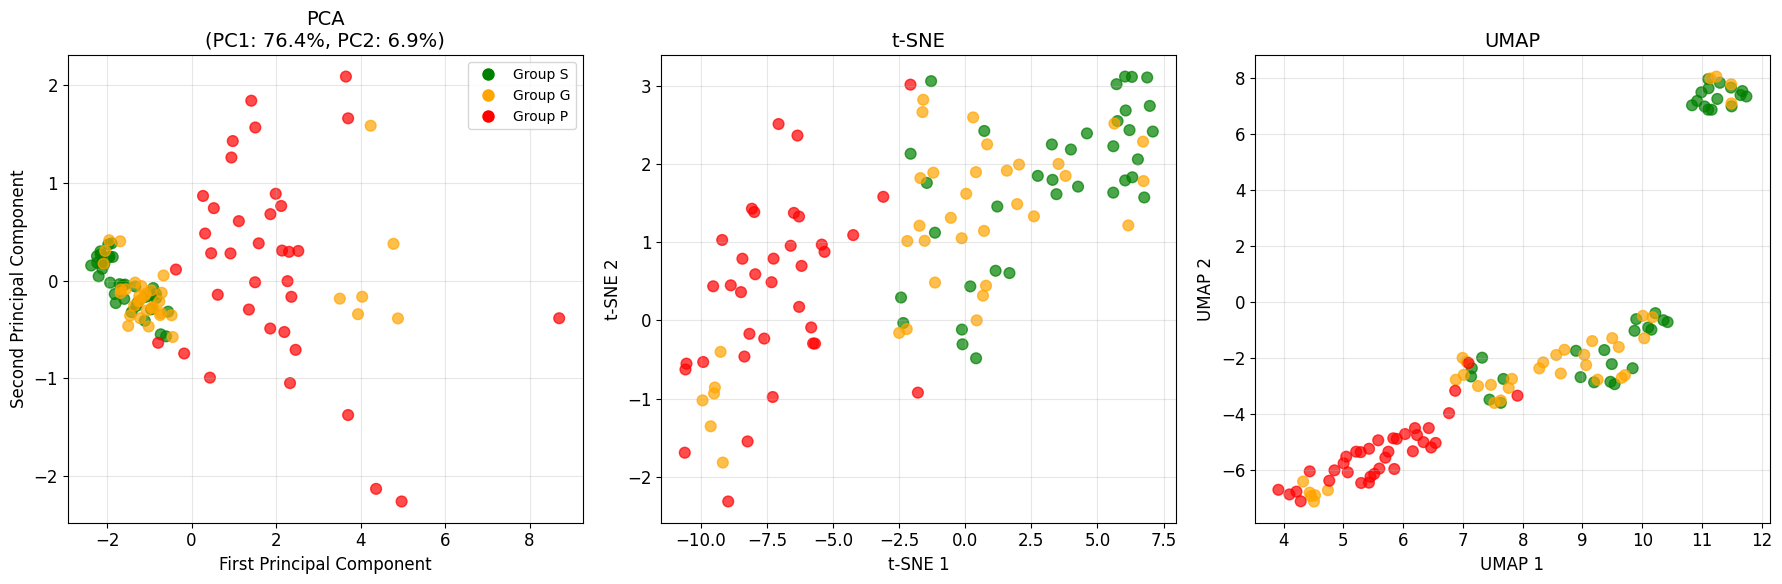


📊 PCA COMPONENT ANALYSIS
Explained variance ratio for first 6 components:
  PC1: 0.764 (76.4%)
  PC2: 0.069 (6.9%)
  PC3: 0.057 (5.7%)
  PC4: 0.044 (4.4%)
  PC5: 0.034 (3.4%)
  PC6: 0.032 (3.2%)
Cumulative explained variance (first 6 components): 1.000

📊 PCA Loadings (First 2 Components):
              PC1    PC2     Feature
RQ_mir146a  0.424 -0.229  RQ_mir146a
RQ_mir223   0.420 -0.177   RQ_mir223
RQ_mir203   0.419  0.161   RQ_mir203
RQ_mir146b  0.409 -0.394  RQ_mir146b
RQ_mir155   0.393 -0.147   RQ_mir155
RQ_mir381p  0.383  0.844  RQ_mir381p

🔍 CLUSTERING VALIDATION
Adjusted Rand Index: 0.373

📊 Cluster Composition:
Cluster        0   1   2  All
Actual_Group                 
G             30   0   6   36
P              3  26   7   36
S             36   0   0   36
All           69  26  13  108


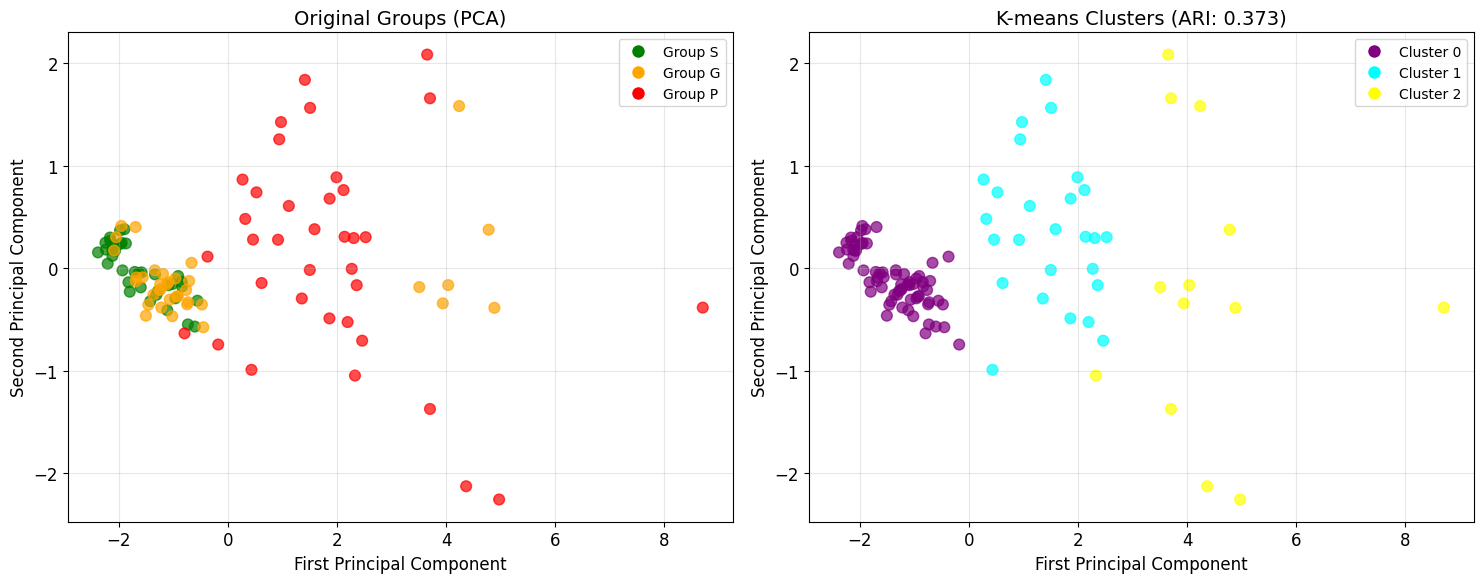


✅ Dimensionality reduction analysis complete!
📊 Plots saved to: outputs/jupyter_notebook/plots\Dimensionality_Reduction.png
📊 Clustering results saved to: outputs/jupyter_notebook/plots\Clustering_Results.png
📊 Cluster composition saved to: outputs/jupyter_notebook/tables\Cluster_Composition.csv


In [13]:
# Dimensionality Reduction Analysis
print("📐 DIMENSIONALITY REDUCTION ANALYSIS")
print("=" * 50)

# Prepare data for dimensionality reduction
rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
X_dr = df[rq_cols].copy()

# Standardize features
scaler = StandardScaler()
X_dr_scaled = scaler.fit_transform(X_dr)

# Color mapping for groups
color_map = {"S": "green", "G": "orange", "P": "red"}
colors = [color_map[group] for group in df["GROUP"]]

# Apply dimensionality reduction techniques
print("🔍 Applying dimensionality reduction techniques...")

# 1. PCA
print("  - Principal Component Analysis (PCA)")
pca = PCA(n_components=2, random_state=ANALYSIS_CONFIG["random_state"])
X_pca = pca.fit_transform(X_dr_scaled)

# 2. t-SNE
print("  - t-Distributed Stochastic Neighbor Embedding (t-SNE)")
tsne = TSNE(
    n_components=2,
    random_state=ANALYSIS_CONFIG["random_state"],
    perplexity=30,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_dr_scaled)

# 3. UMAP
print("  - Uniform Manifold Approximation and Projection (UMAP)")
umap_reducer = umap.UMAP(n_components=2, random_state=ANALYSIS_CONFIG["random_state"])
X_umap = umap_reducer.fit_transform(X_dr_scaled)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA plot
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, s=60)
axes[0].set_title(
    f"PCA\n(PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%})"
)
axes[0].set_xlabel("First Principal Component")
axes[0].set_ylabel("Second Principal Component")
axes[0].grid(True, alpha=0.3)

# t-SNE plot
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.7, s=60)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True, alpha=0.3)

# UMAP plot
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.7, s=60)
axes[2].set_title("UMAP")
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].grid(True, alpha=0.3)

# Add legend
legend_elements = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_map[group],
        markersize=10,
        label=f"Group {group}",
    )
    for group in ANALYSIS_CONFIG["groups"]
]
axes[0].legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig(
    get_output_path("Dimensionality_Reduction.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# PCA component analysis
print("\n📊 PCA COMPONENT ANALYSIS")
print("=" * 50)

pca_full = PCA(random_state=ANALYSIS_CONFIG["random_state"])
pca_full.fit(X_dr_scaled)

print(f"Explained variance ratio for first 6 components:")
for i, var_ratio in enumerate(pca_full.explained_variance_ratio_[:6]):
    print(f"  PC{i+1}: {var_ratio:.3f} ({var_ratio*100:.1f}%)")

print(
    f"Cumulative explained variance (first 6 components): {sum(pca_full.explained_variance_ratio_[:6]):.3f}"
)

# PCA loadings
loadings = pca_full.components_[:2].T  # First 2 components
loading_df = pd.DataFrame(loadings, columns=["PC1", "PC2"], index=rq_cols)
loading_df["Feature"] = loading_df.index
loading_df = loading_df.sort_values("PC1", key=abs, ascending=False)

print("\n📊 PCA Loadings (First 2 Components):")
print(loading_df.round(3))

# K-means clustering validation
print("\n🔍 CLUSTERING VALIDATION")
print("=" * 50)

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=ANALYSIS_CONFIG["random_state"])
cluster_labels = kmeans.fit_predict(X_dr_scaled)

# Calculate adjusted rand score
ari = adjusted_rand_score(df["GROUP"].map({"S": 0, "G": 1, "P": 2}), cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")

# Create cluster composition table
cluster_composition = pd.crosstab(df["GROUP"], cluster_labels, margins=True)
cluster_composition.index.name = "Actual_Group"
cluster_composition.columns.name = "Cluster"

print("\n📊 Cluster Composition:")
print(cluster_composition)

# Save cluster composition
cluster_composition.to_csv(get_output_path("Cluster_Composition.csv", "tables"))

# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original groups
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, s=60)
axes[0].set_title("Original Groups (PCA)")
axes[0].set_xlabel("First Principal Component")
axes[0].set_ylabel("Second Principal Component")
axes[0].grid(True, alpha=0.3)

# Cluster assignments
cluster_colors = ["purple", "cyan", "yellow"]
cluster_color_map = [cluster_colors[label] for label in cluster_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_color_map, alpha=0.7, s=60)
axes[1].set_title(f"K-means Clusters (ARI: {ari:.3f})")
axes[1].set_xlabel("First Principal Component")
axes[1].set_ylabel("Second Principal Component")
axes[1].grid(True, alpha=0.3)

# Add legends
legend_elements_groups = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_map[group],
        markersize=10,
        label=f"Group {group}",
    )
    for group in ANALYSIS_CONFIG["groups"]
]
axes[0].legend(handles=legend_elements_groups, loc="upper right")

legend_elements_clusters = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cluster_colors[i],
        markersize=10,
        label=f"Cluster {i}",
    )
    for i in range(3)
]
axes[1].legend(handles=legend_elements_clusters, loc="upper right")

plt.tight_layout()
plt.savefig(get_output_path("Clustering_Results.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✅ Dimensionality reduction analysis complete!")
print(f"📊 Plots saved to: {get_output_path('Dimensionality_Reduction.png')}")
print(f"📊 Clustering results saved to: {get_output_path('Clustering_Results.png')}")
print(
    f"📊 Cluster composition saved to: {get_output_path('Cluster_Composition.csv', 'tables')}"
)


# 7. Comprehensive Visualization Generation

Additional visualizations including boxplots, scatter plots, and feature importance analysis.

📊 COMPREHENSIVE VISUALIZATION GENERATION
📦 Creating boxplots for pairwise comparisons...


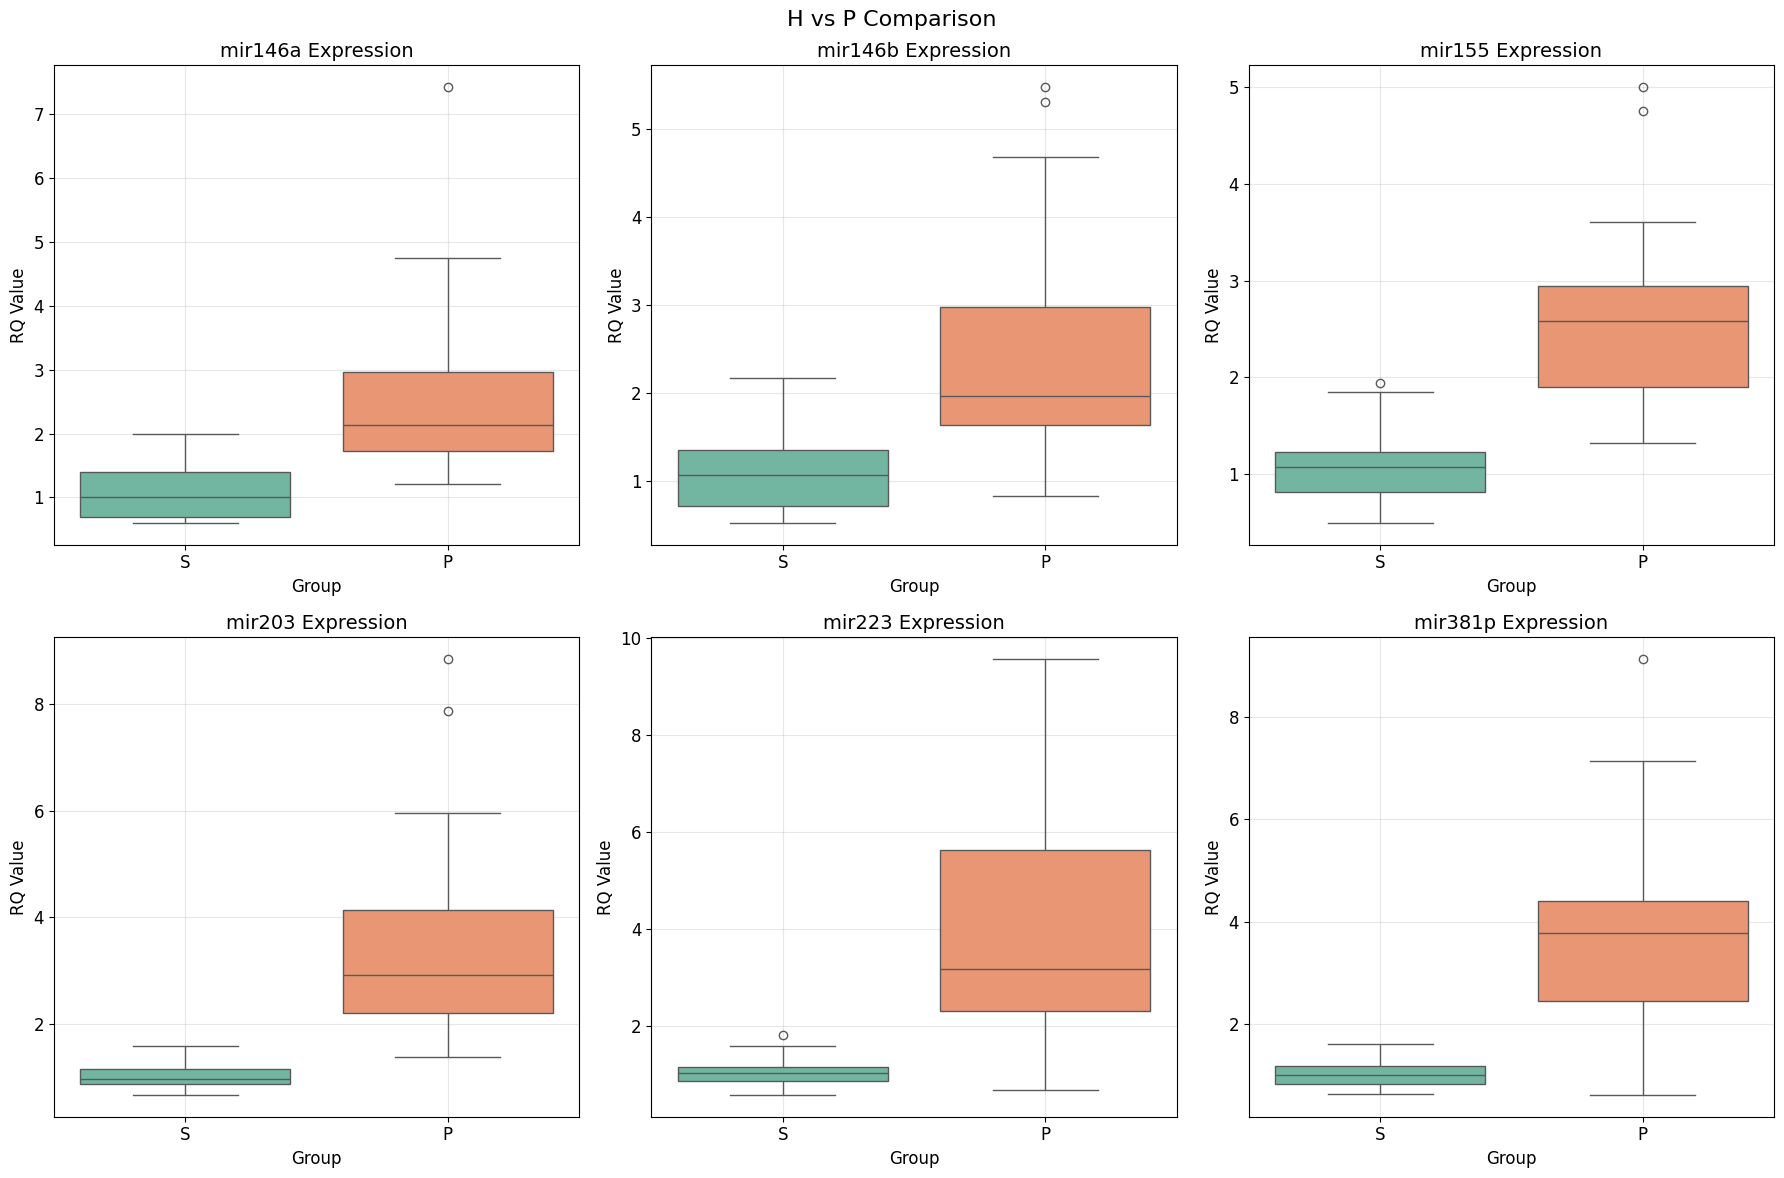

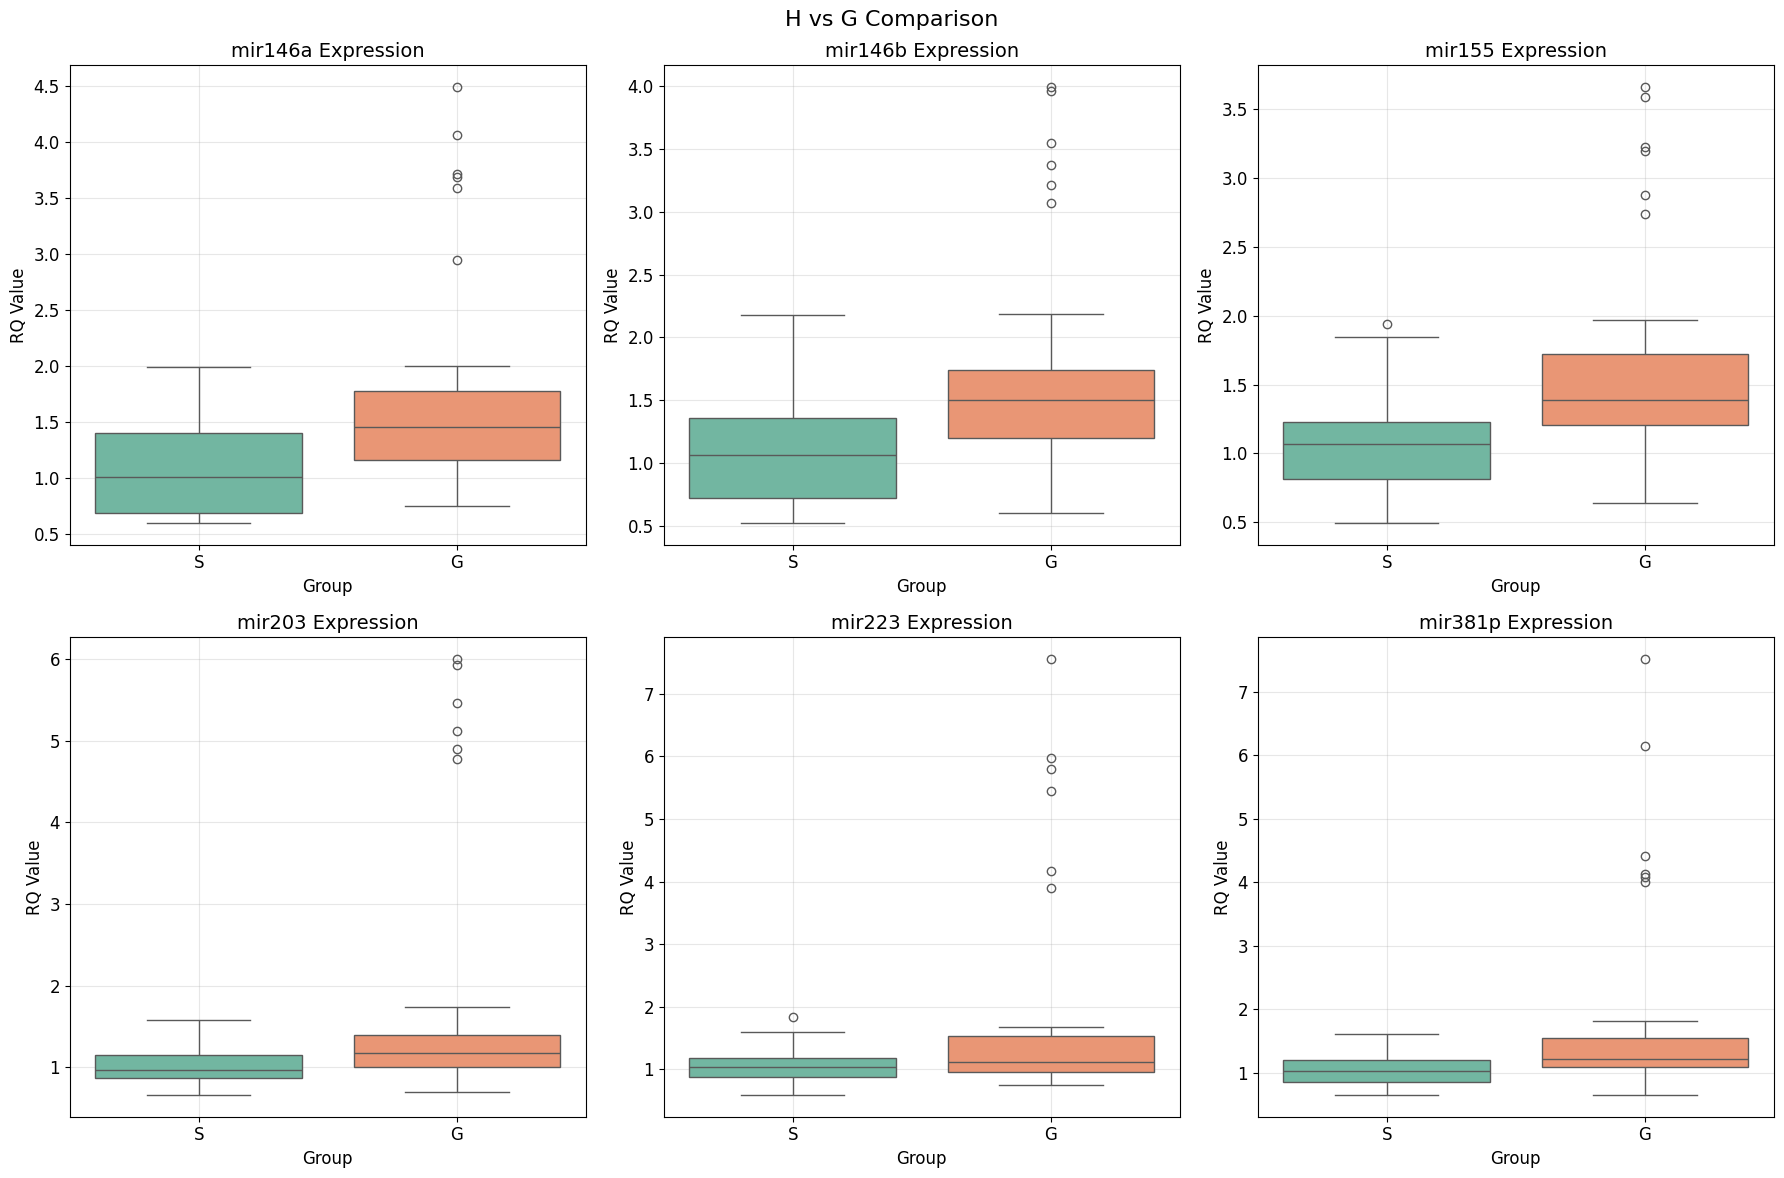

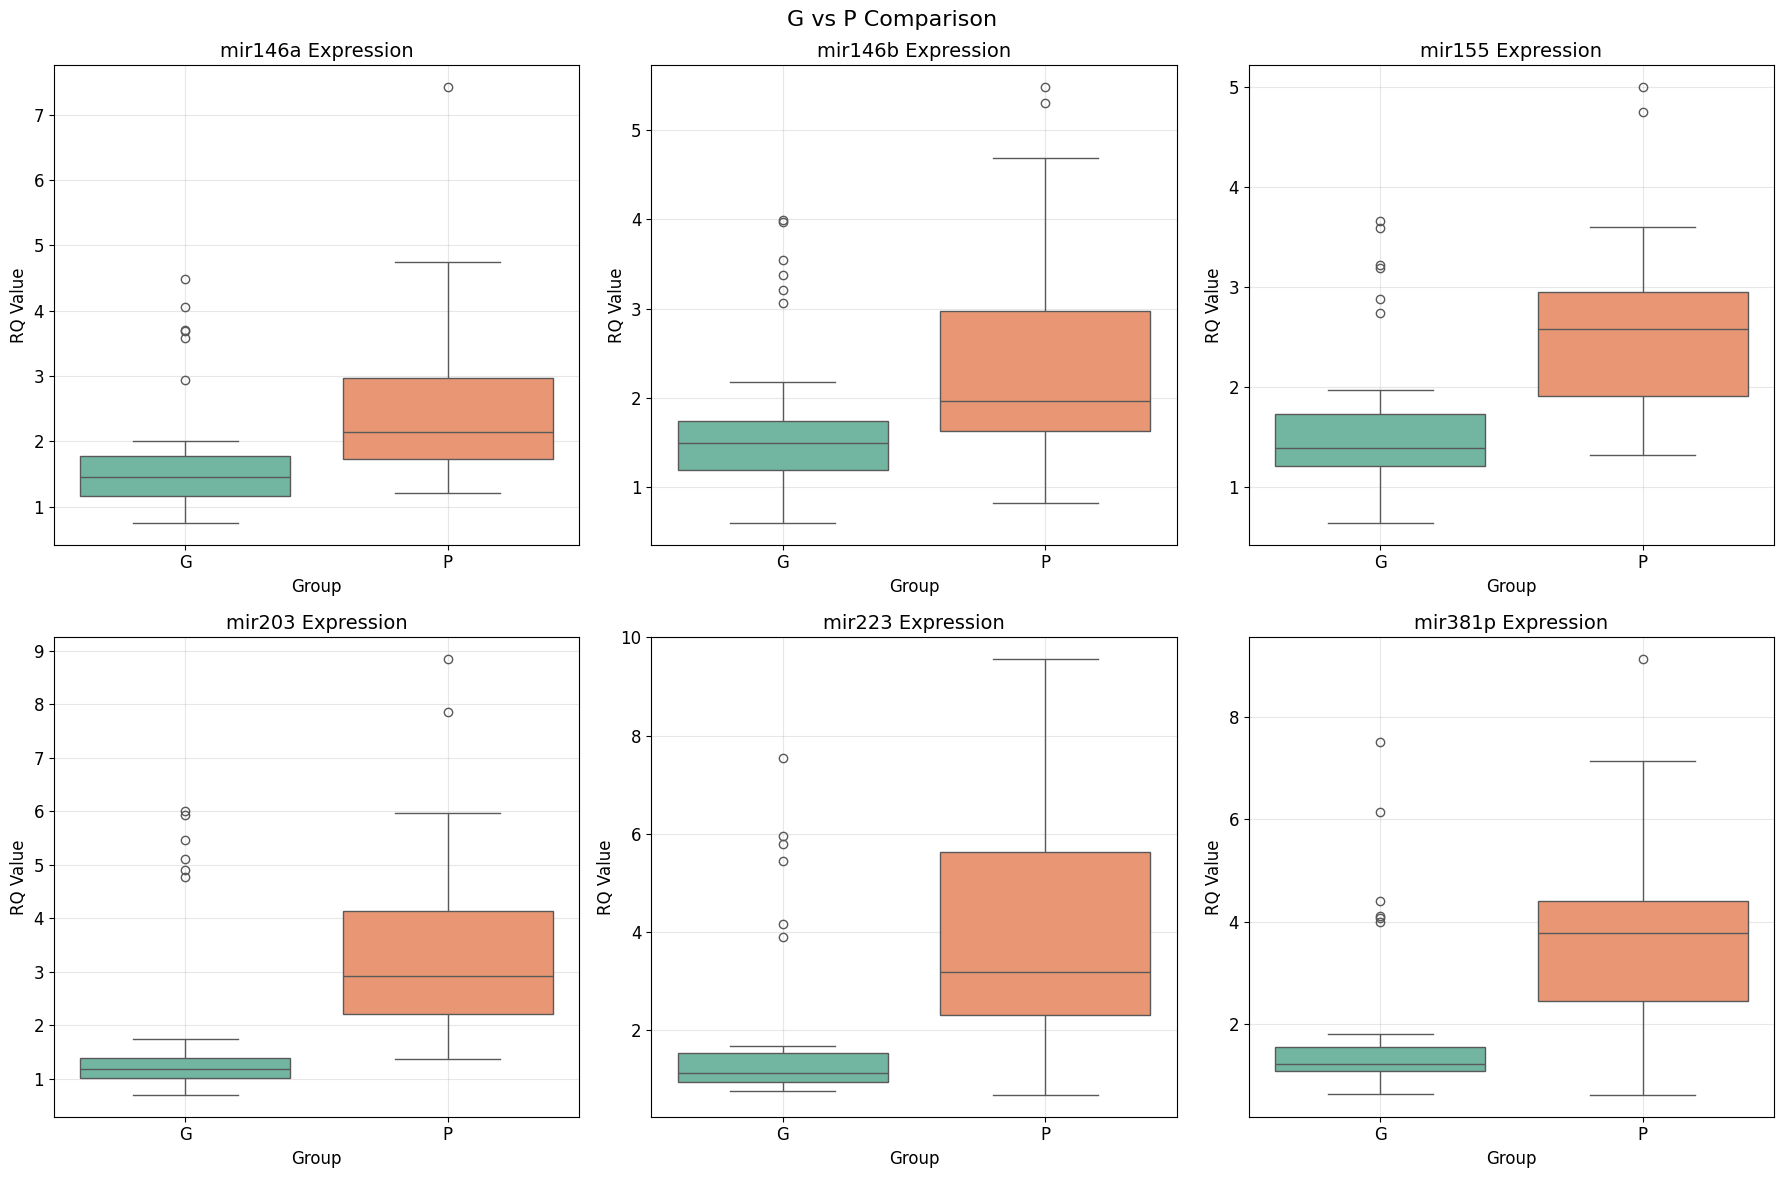

📊 Creating scatter plots for significant correlations...


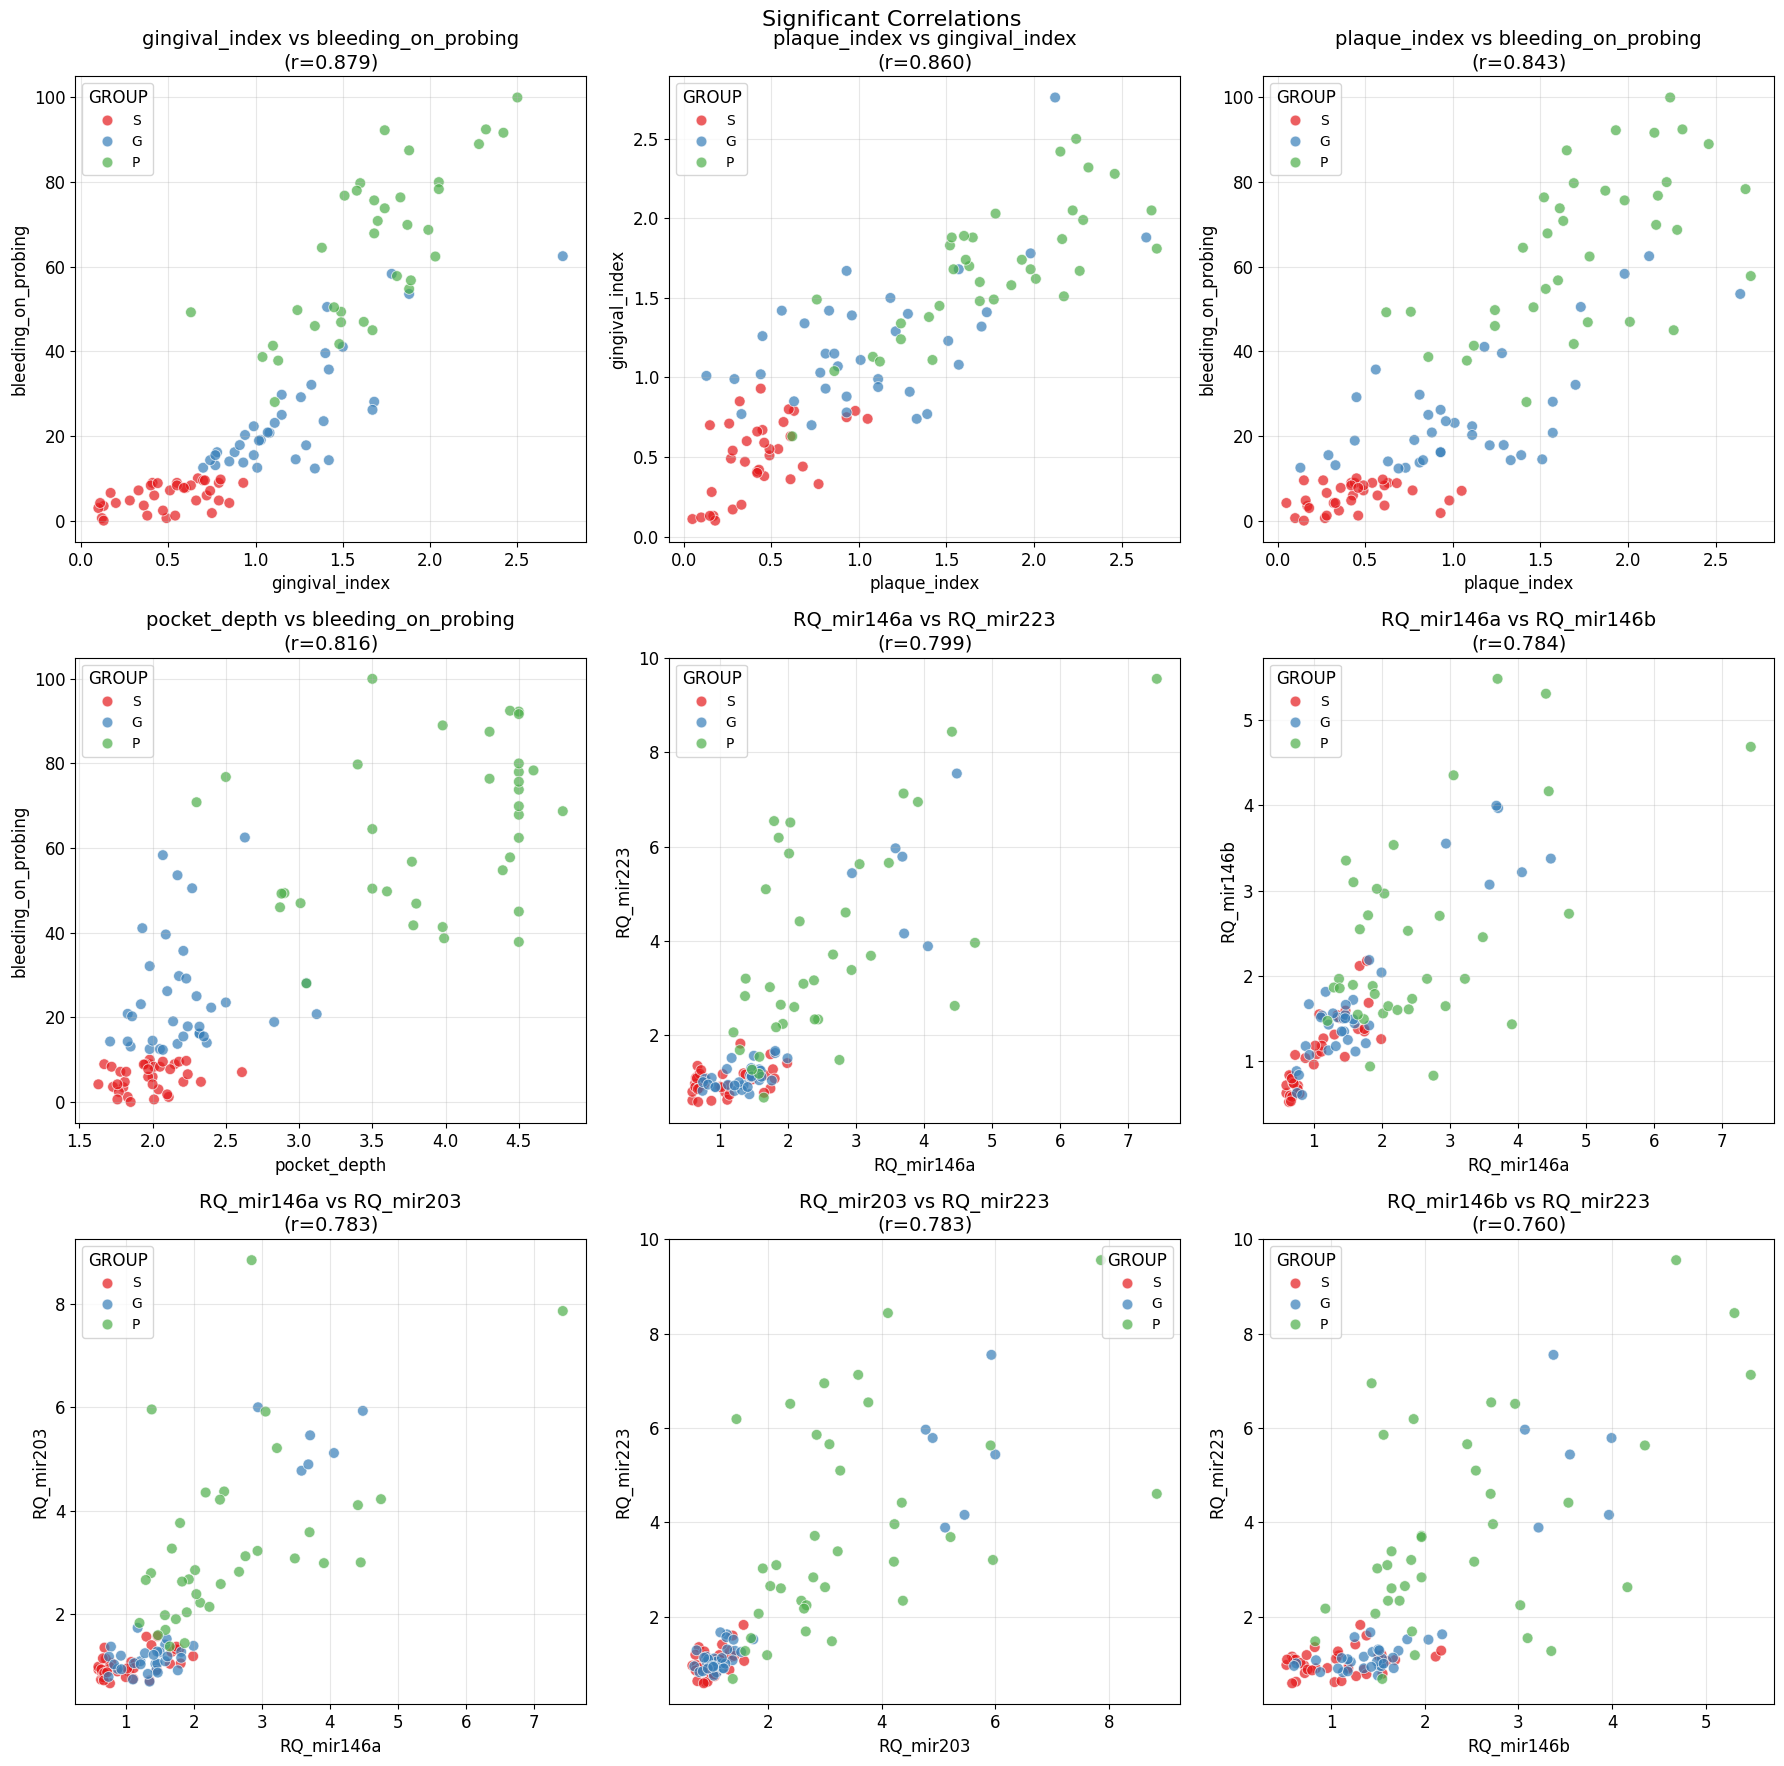

📊 Creating feature importance visualization...


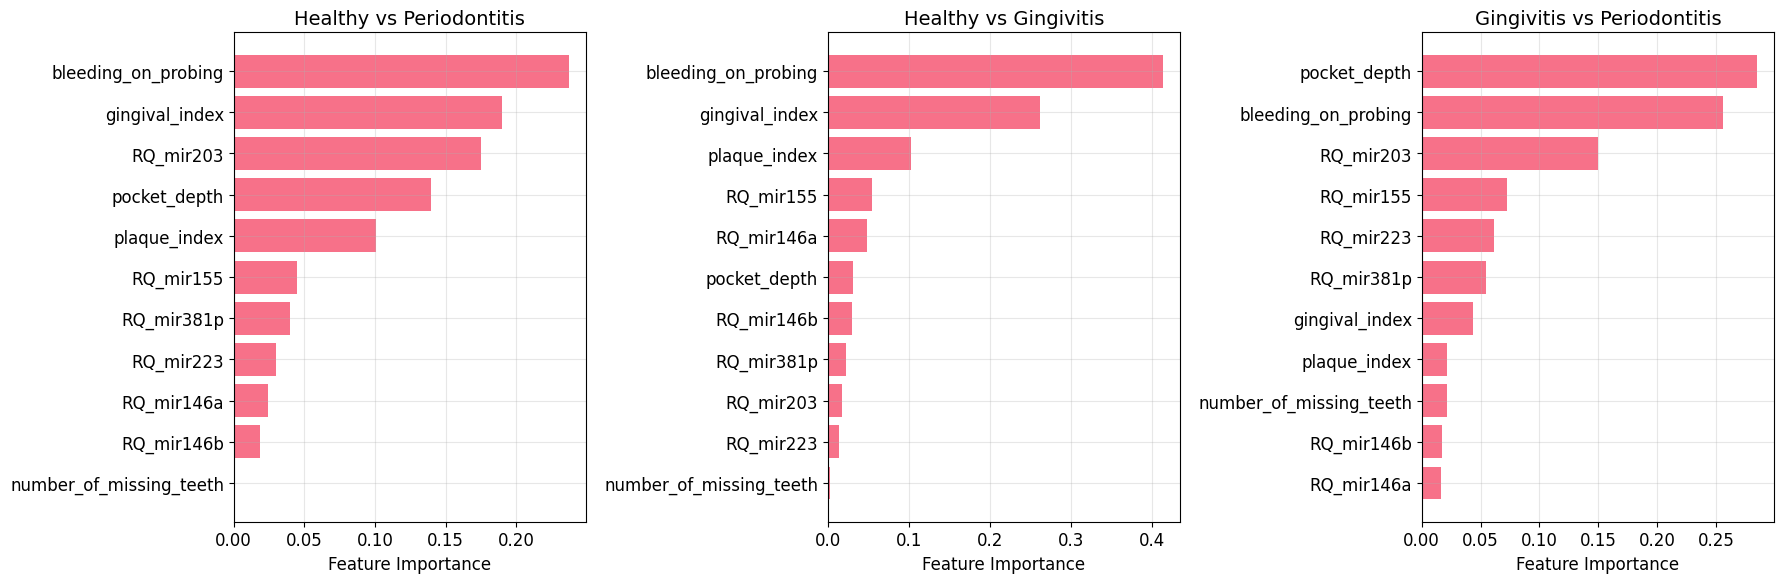

📊 Creating clinical variable correlation heatmap...


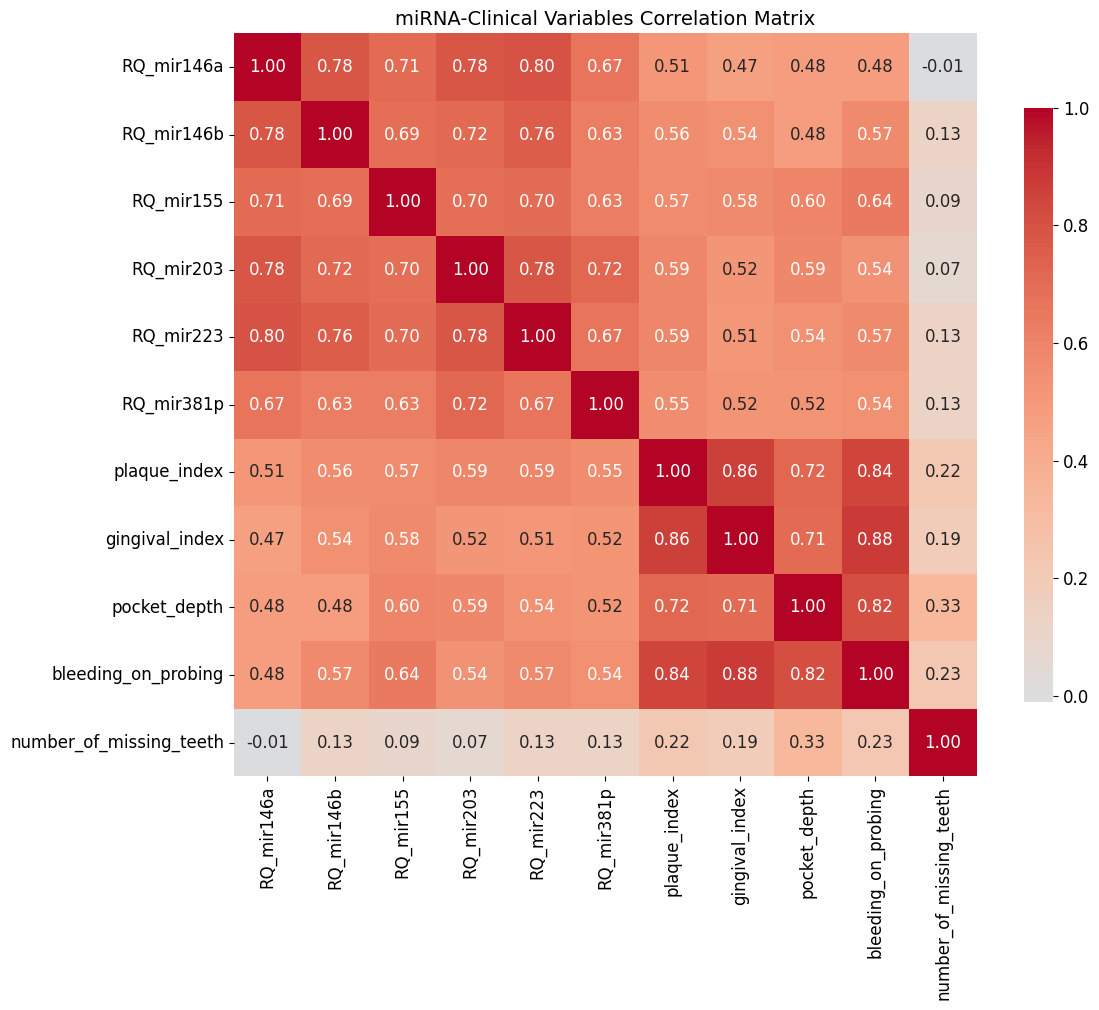

📊 Creating age and clinical variable scatter plots...


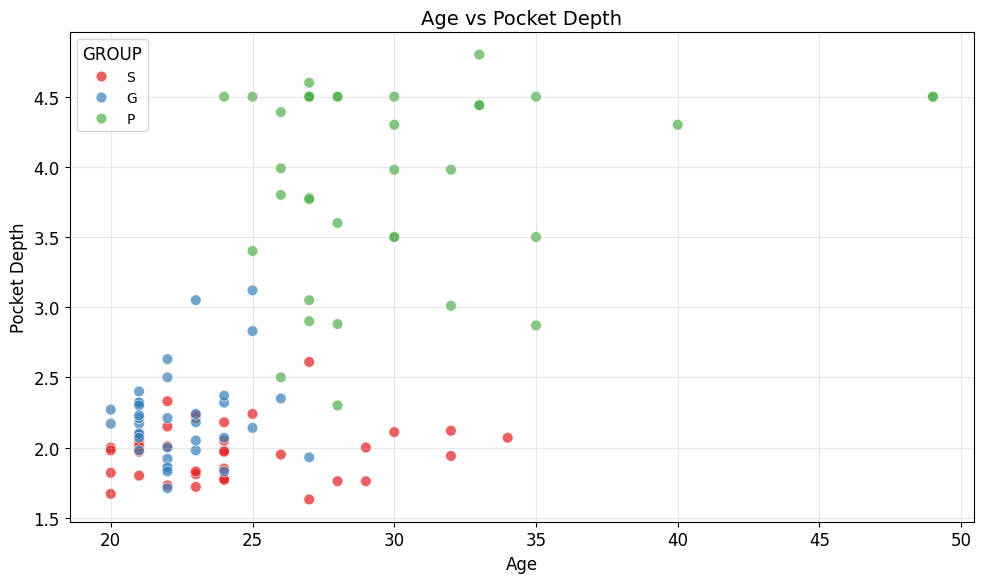

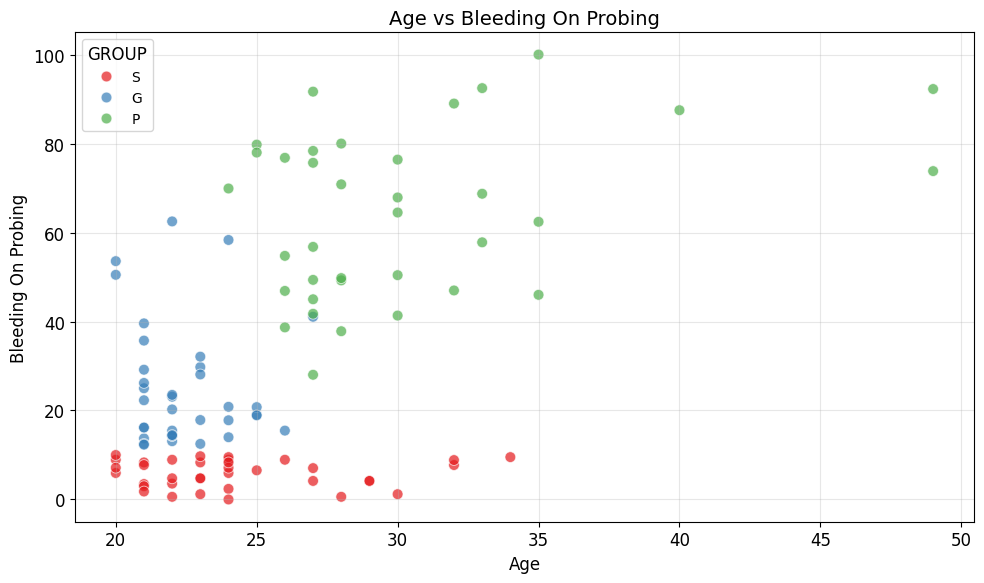

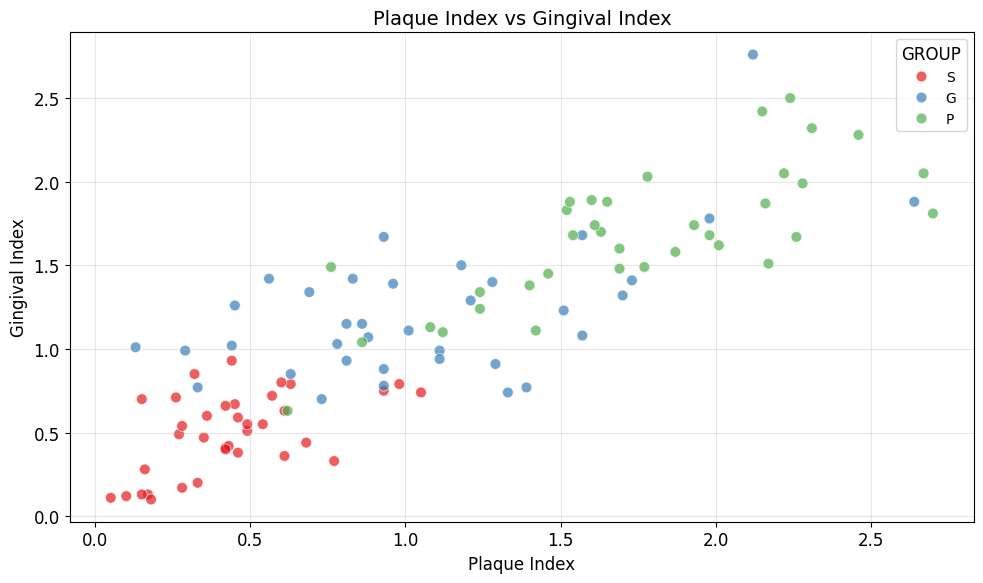

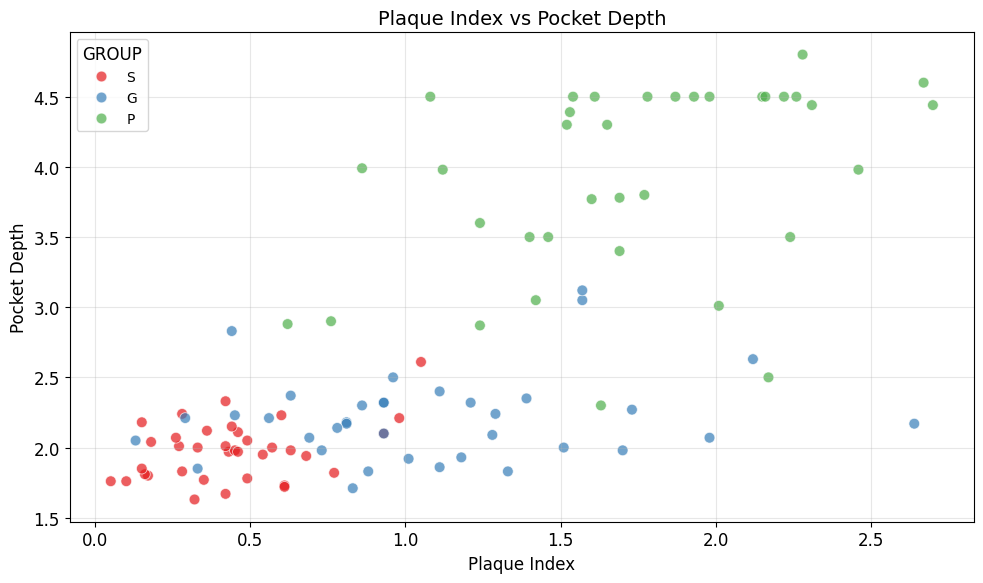

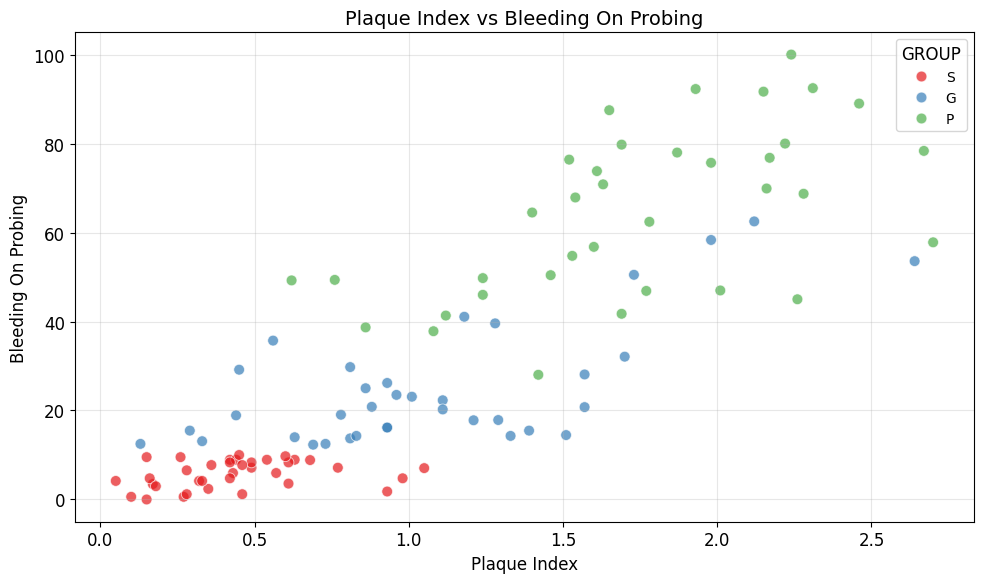

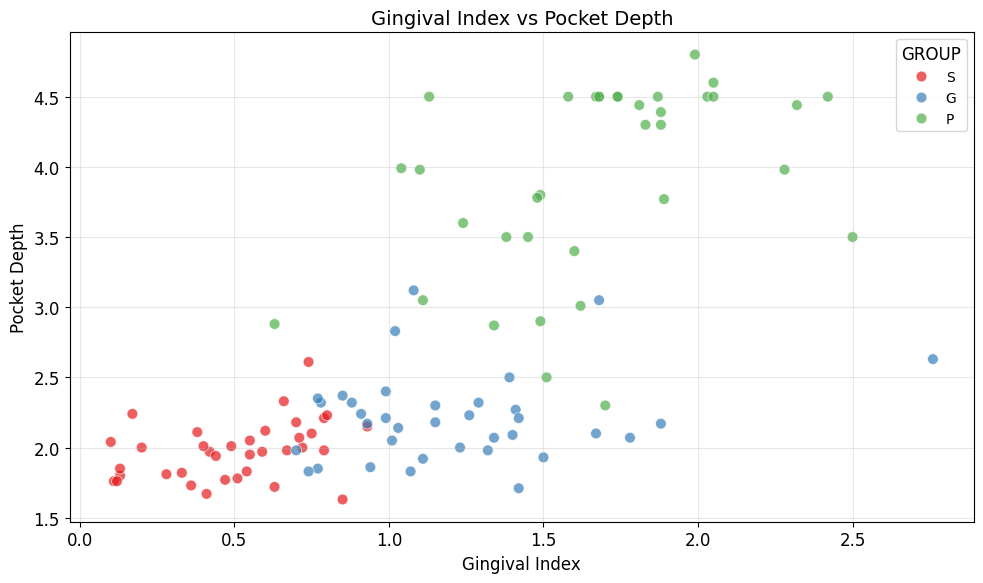

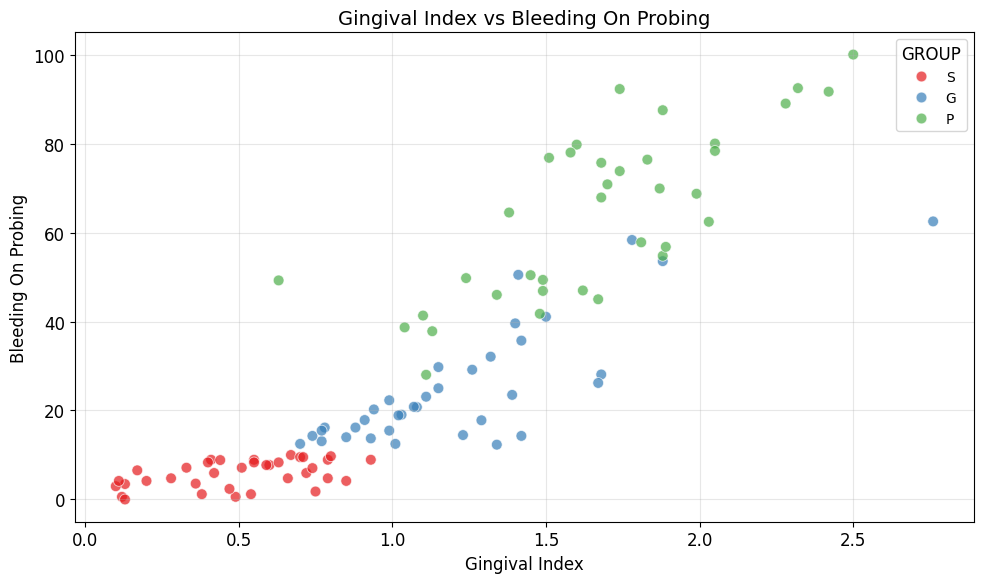

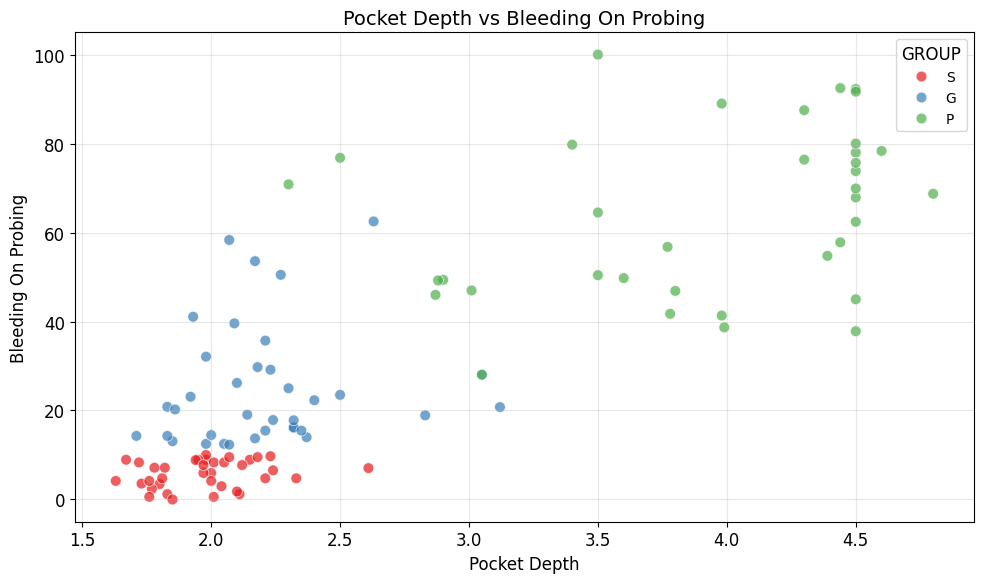

✅ Comprehensive visualization generation complete!
📊 All visualizations saved to: outputs/jupyter_notebook/plots

💾 SAVING PROCESSED DATA
📊 Processed data saved to: outputs/jupyter_notebook/tables\Processed_Data.csv
📊 Shape: (108, 33)
📊 Columns: 33


In [14]:
# Comprehensive Visualization Generation
print("📊 COMPREHENSIVE VISUALIZATION GENERATION")
print("=" * 50)

# 1. Boxplots for pairwise comparisons
print("📦 Creating boxplots for pairwise comparisons...")

for group1, group2, comparison_name in comparison_pairs:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    comparison_data = df[df["GROUP"].isin([group1, group2])]

    for i, mirna in enumerate(ANALYSIS_CONFIG["mirna_names"]):
        rq_col = f"RQ_{mirna}"

        sns.boxplot(
            data=comparison_data,
            x="GROUP",
            y=rq_col,
            ax=axes[i],
            palette="Set2",
            order=[group1, group2],
        )
        axes[i].set_title(f"{mirna} Expression")
        axes[i].set_ylabel("RQ Value")
        axes[i].set_xlabel("Group")
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f'{comparison_name.replace("_", " ")} Comparison', fontsize=16)
    plt.tight_layout()
    plt.savefig(
        get_output_path(f"Boxplots_{comparison_name}.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()

# 2. Scatter plots for significant correlations
print("📊 Creating scatter plots for significant correlations...")

if significant_correlations:
    # Create scatter plots for top correlations
    n_plots = min(9, len(significant_correlations))  # Max 9 plots (3x3 grid)

    if n_plots > 0:
        fig, axes = plt.subplots(3, 3, figsize=(18, 18))
        axes = axes.flatten()

        for i in range(n_plots):
            corr = significant_correlations[i]
            var1, var2 = corr["Variable_1"], corr["Variable_2"]

            # Create scatter plot
            sns.scatterplot(
                data=df,
                x=var1,
                y=var2,
                hue="GROUP",
                ax=axes[i],
                palette="Set1",
                s=60,
                alpha=0.7,
            )
            axes[i].set_title(f'{var1} vs {var2}\n(r={corr["Correlation"]:.3f})')
            axes[i].grid(True, alpha=0.3)

        # Hide unused subplots
        for i in range(n_plots, 9):
            axes[i].set_visible(False)

        plt.suptitle("Significant Correlations", fontsize=16)
        plt.tight_layout()
        plt.savefig(
            get_output_path("Scatter_Plots_Significant_Correlations.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

# 3. Feature importance visualization
print("📊 Creating feature importance visualization...")

# Combine all feature importance results
all_importance_data = []
for problem_name in [comp[2] for comp in binary_problems]:
    try:
        importance_file = get_output_path(
            f"Feature_Importance_{problem_name}.csv", "tables"
        )
        if os.path.exists(importance_file):
            importance_data = pd.read_csv(importance_file)
            all_importance_data.append(importance_data)
    except:
        continue

if all_importance_data:
    combined_importance = pd.concat(all_importance_data, ignore_index=True)

    # Create feature importance plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, problem_name in enumerate([comp[2] for comp in binary_problems]):
        problem_data = combined_importance[
            combined_importance["Problem"] == problem_name
        ]

        if len(problem_data) > 0:
            problem_data = problem_data.sort_values("Importance", ascending=True)

            axes[i].barh(problem_data["Feature"], problem_data["Importance"])
            axes[i].set_title(f'{problem_name.replace("_", " ")}')
            axes[i].set_xlabel("Feature Importance")
            axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(get_output_path("Feature_Importance.png"), dpi=300, bbox_inches="tight")
    plt.show()

# 4. Clinical variable correlation heatmap
print("📊 Creating clinical variable correlation heatmap...")

# miRNA-clinical correlation matrix
mirna_clinical_vars = [
    f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]
] + ANALYSIS_CONFIG["clinical_vars"]
mirna_clinical_data = df[mirna_clinical_vars].select_dtypes(include=[np.number])

if len(mirna_clinical_data.columns) > 1:
    mirna_clinical_corr = mirna_clinical_data.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        mirna_clinical_corr,
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        fmt=".2f",
        cbar_kws={"shrink": 0.8},
    )
    plt.title("miRNA-Clinical Variables Correlation Matrix")
    plt.tight_layout()
    plt.savefig(
        get_output_path("Correlation_Heatmap_miRNA_Clinical.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

# 5. Age and clinical scatter plots
print("📊 Creating age and clinical variable scatter plots...")

clinical_scatter_plots = [
    ("AGE", "pocket_depth"),
    ("AGE", "bleeding_on_probing"),
    ("plaque_index", "gingival_index"),
    ("plaque_index", "pocket_depth"),
    ("plaque_index", "bleeding_on_probing"),
    ("gingival_index", "pocket_depth"),
    ("gingival_index", "bleeding_on_probing"),
    ("pocket_depth", "bleeding_on_probing"),
]

for var1, var2 in clinical_scatter_plots:
    if var1 in df.columns and var2 in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=df, x=var1, y=var2, hue="GROUP", palette="Set1", s=60, alpha=0.7
        )
        plt.title(
            f'{var1.replace("_", " ").title()} vs {var2.replace("_", " ").title()}'
        )
        plt.xlabel(var1.replace("_", " ").title())
        plt.ylabel(var2.replace("_", " ").title())
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Format filename
        filename = f"Scatter_{var1.title()}_{var2.title()}.png"
        filename = filename.replace("_", "_")
        plt.savefig(get_output_path(filename), dpi=300, bbox_inches="tight")
        plt.show()

print("✅ Comprehensive visualization generation complete!")
print(f"📊 All visualizations saved to: {OUTPUT_DIRS['plots']}")

# Save processed data
print("\n💾 SAVING PROCESSED DATA")
print("=" * 50)

# Create comprehensive processed dataset
processed_data = df.copy()
processed_data.to_csv(get_output_path("Processed_Data.csv", "tables"), index=False)

print(f"📊 Processed data saved to: {get_output_path('Processed_Data.csv', 'tables')}")
print(f"📊 Shape: {processed_data.shape}")
print(f"📊 Columns: {len(processed_data.columns)}")


# 8. Results Export and Documentation

Final summary of results, file organization, and documentation updates.

In [15]:
# Create Comprehensive Analysis-Ready Dataset
print("📊 CREATING CONSOLIDATED ANALYSIS-READY DATASET")
print("=" * 60)

# Start with the main dataset
consolidated_data = df.copy()

# Ensure all required columns exist
required_columns = (
    ["SAMPLE_ID", "GROUP", "AGE", "SEX"]
    + ANALYSIS_CONFIG["mirna_targets"]
    + ["GAPDH"]
    + ANALYSIS_CONFIG["clinical_vars"]
)
existing_columns = [col for col in required_columns if col in consolidated_data.columns]

print(f"📋 Base dataset shape: {consolidated_data.shape}")
print(f"📋 Available columns: {len(existing_columns)}/{len(required_columns)}")

# Add computed columns (RQ values, dCt, ddCt)
rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
dct_cols = [f"dCt_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
ddct_cols = [f"ddCt_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]

# Add statistical analysis results as metadata
print("\n📊 Adding statistical analysis metadata...")

# Create summary statistics by group
group_stats = {}
for group in ANALYSIS_CONFIG["groups"]:
    group_data = consolidated_data[consolidated_data["GROUP"] == group]
    group_stats[group] = {
        "n_samples": len(group_data),
        "mean_age": group_data["AGE"].mean() if "AGE" in group_data.columns else None,
        "sex_distribution": (
            group_data["SEX"].value_counts().to_dict()
            if "SEX" in group_data.columns
            else None
        ),
    }

# Add RQ statistics for each miRNA by group
for mirna in ANALYSIS_CONFIG["mirna_names"]:
    clean_mirna = mirna.replace("mean_", "")
    rq_col = f"RQ_{clean_mirna}"
    if rq_col in consolidated_data.columns:
        for group in ANALYSIS_CONFIG["groups"]:
            group_data = consolidated_data[consolidated_data["GROUP"] == group][rq_col]
            group_stats[group][f"{clean_mirna}_mean_RQ"] = group_data.mean()
            group_stats[group][f"{clean_mirna}_median_RQ"] = group_data.median()
            group_stats[group][f"{clean_mirna}_std_RQ"] = group_data.std()

# Add clinical variable statistics
for clinical_var in ANALYSIS_CONFIG["clinical_vars"]:
    if clinical_var in consolidated_data.columns:
        for group in ANALYSIS_CONFIG["groups"]:
            group_data = consolidated_data[consolidated_data["GROUP"] == group][
                clinical_var
            ]
            group_stats[group][f"{clinical_var}_mean"] = group_data.mean()
            group_stats[group][f"{clinical_var}_median"] = group_data.median()
            group_stats[group][f"{clinical_var}_std"] = group_data.std()

# Add overall statistics
overall_stats = consolidated_data.describe().T
overall_stats["mean"] = overall_stats["mean"].round(3)
overall_stats["std"] = overall_stats["std"].round(3)
overall_stats["min"] = overall_stats["min"].round(3)
overall_stats["25%"] = overall_stats["25%"].round(3)
overall_stats["50%"] = overall_stats["50%"].round(3)
overall_stats["75%"] = overall_stats["75%"].round(3)
overall_stats["max"] = overall_stats["max"].round(3)

# Save overall statistics
overall_stats.to_csv(get_output_path("Overall_Statistics.csv", "tables"))

# Add overall statistics to summary
summary_stats = []
for group, stats in group_stats.items():
    summary_stats.append(
        {
            "Group": group,
            "N": stats["n_samples"],
            "Mean_Age": stats["mean_age"],
            "Sex_Distribution": stats["sex_distribution"],
        }
    )

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(
    get_output_path("Group_Summary_Statistics.csv", "tables"), index=False
)

# Create comprehensive metadata dictionary
metadata = {
    "dataset_info": {
        "total_samples": len(consolidated_data),
        "groups": ANALYSIS_CONFIG["groups"],
        "mirnas_analyzed": ANALYSIS_CONFIG["mirna_names"],
        "clinical_variables": ANALYSIS_CONFIG["clinical_vars"],
        "analysis_date": datetime.now().isoformat(),
    },
    "group_statistics": group_stats,
    "data_quality": {
        "missing_values": consolidated_data.isnull().sum().to_dict(),
        "data_types": consolidated_data.dtypes.astype(str).to_dict(),
    },
}

# Save metadata as JSON
metadata_path = get_output_path("Analysis_Metadata.json", "tables")
try:
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)
    print(f"  ✅ Metadata saved to: {metadata_path}")
except Exception as e:
    print(f"  ❌ Error saving metadata: {str(e)}")

# Clean data - handle missing values
print("\n🔧 Data cleaning and preparation...")

# Check for missing values
missing_summary = consolidated_data.isnull().sum()
if missing_summary.any():
    print("Missing values detected:")
    for col, count in missing_summary[missing_summary > 0].items():
        print(
            f"  {col}: {count} missing values ({count/len(consolidated_data)*100:.1f}%)"
        )

    # Handle missing values intelligently
    for col in consolidated_data.columns:
        if consolidated_data[col].isnull().any():
            if consolidated_data[col].dtype in ["float64", "int64"]:
                # For numerical data, use group-specific median imputation
                for group in ANALYSIS_CONFIG["groups"]:
                    group_mask = consolidated_data["GROUP"] == group
                    group_median = consolidated_data.loc[group_mask, col].median()
                    consolidated_data.loc[
                        group_mask & consolidated_data[col].isnull(), col
                    ] = group_median
                print(f"  ✓ Filled missing values in {col} with group-specific medians")
            else:
                # For categorical data, use mode
                mode_value = (
                    consolidated_data[col].mode()[0]
                    if not consolidated_data[col].mode().empty
                    else "Unknown"
                )
                consolidated_data[col].fillna(mode_value, inplace=True)
                print(f"  ✓ Filled missing values in {col} with mode: {mode_value}")
else:
    print("✅ No missing values detected")

# Add derived features for analysis
print("\n📈 Adding derived features...")

# Age groups
if "AGE" in consolidated_data.columns:
    consolidated_data["AGE_GROUP"] = pd.cut(
        consolidated_data["AGE"],
        bins=[0, 30, 50, 70, 100],
        labels=["Young", "Adult", "Middle", "Senior"],
    )
    print("  ✓ Added AGE_GROUP categories")

# Disease severity score (if clinical variables available)
clinical_score_cols = [
    col
    for col in ["plaque_index", "gingival_index", "pocket_depth", "bleeding_on_probing"]
    if col in consolidated_data.columns
]
if clinical_score_cols:
    # Normalize clinical variables to 0-1 scale
    normalized_clinical = consolidated_data[clinical_score_cols].copy()
    for col in clinical_score_cols:
        normalized_clinical[col] = (
            normalized_clinical[col] - normalized_clinical[col].min()
        ) / (normalized_clinical[col].max() - normalized_clinical[col].min())

    consolidated_data["DISEASE_SEVERITY_SCORE"] = normalized_clinical.mean(axis=1)
    print("  ✓ Added DISEASE_SEVERITY_SCORE (normalized clinical composite)")

# miRNA expression patterns
rq_available = [col for col in rq_cols if col in consolidated_data.columns]
if rq_available:
    consolidated_data["MIRNA_EXPRESSION_MEAN"] = consolidated_data[rq_available].mean(
        axis=1
    )
    consolidated_data["MIRNA_EXPRESSION_STD"] = consolidated_data[rq_available].std(
        axis=1
    )
    print("  ✓ Added miRNA expression summary statistics")

# Add analysis results as flags
print("\n🏷️ Adding analysis result flags...")

# Add significant biomarker flags
if "all_significant" in locals() and all_significant:
    significant_mirnas = list(set([result["miRNA"] for result in all_significant]))
    for mirna in significant_mirnas:
        consolidated_data[f"{mirna}_SIGNIFICANT_BIOMARKER"] = True
        print(f"  ✓ Added {mirna}_SIGNIFICANT_BIOMARKER flag")

# Add group comparison flags
for group1, group2, comparison_name in [
    ("S", "P", "H_vs_P"),
    ("S", "G", "H_vs_G"),
    ("G", "P", "G_vs_P"),
]:
    mask_group1 = consolidated_data["GROUP"] == group1
    mask_group2 = consolidated_data["GROUP"] == group2
    consolidated_data[f"INCLUDED_IN_{comparison_name}"] = mask_group1 | mask_group2
    print(f"  ✓ Added INCLUDED_IN_{comparison_name} flag")

print(f"\n📊 Final consolidated dataset shape: {consolidated_data.shape}")
print(f"📊 Total columns: {len(consolidated_data.columns)}")

# Sort columns for better organization
column_order = []

# Core identification columns
core_cols = (
    ["SAMPLE_ID", "GROUP", "AGE", "SEX", "AGE_GROUP"]
    if "SAMPLE_ID" in consolidated_data.columns
    else ["GROUP", "AGE", "SEX", "AGE_GROUP"]
)
core_cols = [col for col in core_cols if col in consolidated_data.columns]
column_order.extend(core_cols)

# Raw qPCR data
raw_qpcr_cols = ANALYSIS_CONFIG["mirna_targets"] + ["GAPDH"]
raw_qpcr_cols = [col for col in raw_qpcr_cols if col in consolidated_data.columns]
column_order.extend(raw_qpcr_cols)

# Processed expression data
processed_cols = dct_cols + ddct_cols + rq_cols
processed_cols = [col for col in processed_cols if col in consolidated_data.columns]
column_order.extend(processed_cols)

# Clinical variables
clinical_cols = [
    col for col in ANALYSIS_CONFIG["clinical_vars"] if col in consolidated_data.columns
]
column_order.extend(clinical_cols)

# Derived features
derived_cols = [
    "DISEASE_SEVERITY_SCORE",
    "MIRNA_EXPRESSION_MEAN",
    "MIRNA_EXPRESSION_STD",
]
derived_cols = [col for col in derived_cols if col in consolidated_data.columns]
column_order.extend(derived_cols)

# Analysis flags
flag_cols = [
    col
    for col in consolidated_data.columns
    if col.endswith("_SIGNIFICANT_BIOMARKER") or col.startswith("INCLUDED_IN_")
]
column_order.extend(flag_cols)

# Any remaining columns
remaining_cols = [col for col in consolidated_data.columns if col not in column_order]
column_order.extend(remaining_cols)

# Reorder columns
consolidated_data = consolidated_data[column_order]

print("\n📋 COLUMN ORGANIZATION:")
print(f"  Core Info: {len(core_cols)} columns")
print(f"  Raw qPCR: {len(raw_qpcr_cols)} columns")
print(f"  Processed Expression: {len(processed_cols)} columns")
print(f"  Clinical: {len(clinical_cols)} columns")
print(f"  Derived Features: {len(derived_cols)} columns")
print(f"  Analysis Flags: {len(flag_cols)} columns")
print(f"  Other: {len(remaining_cols)} columns")


📊 CREATING CONSOLIDATED ANALYSIS-READY DATASET
📋 Base dataset shape: (108, 33)
📋 Available columns: 14/16

📊 Adding statistical analysis metadata...
  ✅ Metadata saved to: outputs/jupyter_notebook/tables\Analysis_Metadata.json.png

🔧 Data cleaning and preparation...
✅ No missing values detected

📈 Adding derived features...
  ✓ Added AGE_GROUP categories
  ✓ Added DISEASE_SEVERITY_SCORE (normalized clinical composite)
  ✓ Added miRNA expression summary statistics

🏷️ Adding analysis result flags...
  ✓ Added mir146a_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir155_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir223_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir203_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir381p_SIGNIFICANT_BIOMARKER flag
  ✓ Added INCLUDED_IN_H_vs_P flag
  ✓ Added INCLUDED_IN_H_vs_G flag
  ✓ Added INCLUDED_IN_G_vs_P flag

📊 Final consolidated dataset shape: (108, 45)
📊 Total columns: 45

📋 COLUMN ORGANIZATION:
  Core Info: 4 columns
  Raw qPCR: 6 columns
  Processed Expression: 18 columns
 

# 9. Consolidated Analysis-Ready Dataset Creation

Creating a single, comprehensive file that consolidates all analysis results for easy use with AI tools, Google Sheets, or Excel.

In [16]:
# Create Comprehensive Analysis-Ready Dataset
print("📊 CREATING CONSOLIDATED ANALYSIS-READY DATASET")
print("=" * 60)

# Start with the main dataset
consolidated_data = df.copy()

# Ensure all required columns exist
required_columns = (
    ["SAMPLE_ID", "GROUP", "AGE", "SEX"]
    + ANALYSIS_CONFIG["mirna_targets"]
    + ["GAPDH"]
    + ANALYSIS_CONFIG["clinical_vars"]
)
existing_columns = [col for col in required_columns if col in consolidated_data.columns]

print(f"📋 Base dataset shape: {consolidated_data.shape}")
print(f"📋 Available columns: {len(existing_columns)}/{len(required_columns)}")

# Add computed columns (RQ values, dCt, ddCt)
rq_cols = [f"RQ_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
dct_cols = [f"dCt_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]
ddct_cols = [f"ddCt_{mirna}" for mirna in ANALYSIS_CONFIG["mirna_names"]]

# Add statistical analysis results as metadata
print("\n📊 Adding statistical analysis metadata...")

# Create summary statistics by group
group_stats = {}
for group in ANALYSIS_CONFIG["groups"]:
    group_data = consolidated_data[consolidated_data["GROUP"] == group]
    group_stats[group] = {
        "n_samples": len(group_data),
        "mean_age": group_data["AGE"].mean() if "AGE" in group_data.columns else None,
        "sex_distribution": (
            group_data["SEX"].value_counts().to_dict()
            if "SEX" in group_data.columns
            else None
        ),
    }

# Add RQ statistics for each miRNA by group
for mirna in ANALYSIS_CONFIG["mirna_targets"]:
    rq_col = f"RQ_{mirna}"
    if rq_col in consolidated_data.columns:
        for group in ANALYSIS_CONFIG["groups"]:
            group_data = consolidated_data[consolidated_data["GROUP"] == group][rq_col]
            group_stats[group][f"{mirna}_mean_RQ"] = group_data.mean()
            group_stats[group][f"{mirna}_median_RQ"] = group_data.median()
            group_stats[group][f"{mirna}_std_RQ"] = group_data.std()

# Add clinical variable statistics
for clinical_var in ANALYSIS_CONFIG["clinical_vars"]:
    if clinical_var in consolidated_data.columns:
        for group in ANALYSIS_CONFIG["groups"]:
            group_data = consolidated_data[consolidated_data["GROUP"] == group][
                clinical_var
            ]
            group_stats[group][f"{clinical_var}_mean"] = group_data.mean()
            group_stats[group][f"{clinical_var}_median"] = group_data.median()
            group_stats[group][f"{clinical_var}_std"] = group_data.std()

# Add overall statistics
overall_stats = consolidated_data.describe().T
overall_stats["mean"] = overall_stats["mean"].round(3)
overall_stats["std"] = overall_stats["std"].round(3)
overall_stats["min"] = overall_stats["min"].round(3)
overall_stats["25%"] = overall_stats["25%"].round(3)
overall_stats["50%"] = overall_stats["50%"].round(3)
overall_stats["75%"] = overall_stats["75%"].round(3)
overall_stats["max"] = overall_stats["max"].round(3)

# Save overall statistics
overall_stats.to_csv(get_output_path("Overall_Statistics.csv", "tables"))

# Add overall statistics to summary
summary_stats = []
for group, stats in group_stats.items():
    summary_stats.append(
        {
            "Group": group,
            "N": stats["n_samples"],
            "Mean_Age": stats["mean_age"],
            "Sex_Distribution": stats["sex_distribution"],
        }
    )

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(
    get_output_path("Group_Summary_Statistics.csv", "tables"), index=False
)

# Create comprehensive metadata dictionary
metadata = {
    "dataset_info": {
        "total_samples": len(consolidated_data),
        "groups": ANALYSIS_CONFIG["groups"],
        "mirnas_analyzed": ANALYSIS_CONFIG["mirna_names"],
        "clinical_variables": ANALYSIS_CONFIG["clinical_vars"],
        "analysis_date": datetime.now().isoformat(),
    },
    "group_statistics": group_stats,
    "data_quality": {
        "missing_values": consolidated_data.isnull().sum().to_dict(),
        "data_types": consolidated_data.dtypes.astype(str).to_dict(),
    },
}

# Save metadata as JSON
metadata_path = get_output_path("Analysis_Metadata.json", "tables")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"  ✅ Metadata saved to: {metadata_path}")

# Clean data - handle missing values
print("\n🔧 Data cleaning and preparation...")

# Check for missing values
missing_summary = consolidated_data.isnull().sum()
if missing_summary.any():
    print("Missing values detected:")
    for col, count in missing_summary[missing_summary > 0].items():
        print(
            f"  {col}: {count} missing values ({count/len(consolidated_data)*100:.1f}%)"
        )

    # Handle missing values intelligently
    for col in consolidated_data.columns:
        if consolidated_data[col].isnull().any():
            if consolidated_data[col].dtype in ["float64", "int64"]:
                # For numerical data, use group-specific median imputation
                for group in ANALYSIS_CONFIG["groups"]:
                    group_mask = consolidated_data["GROUP"] == group
                    group_median = consolidated_data.loc[group_mask, col].median()
                    consolidated_data.loc[
                        group_mask & consolidated_data[col].isnull(), col
                    ] = group_median
                print(f"  ✓ Filled missing values in {col} with group-specific medians")
            else:
                # For categorical data, use mode
                mode_value = (
                    consolidated_data[col].mode()[0]
                    if not consolidated_data[col].mode().empty
                    else "Unknown"
                )
                consolidated_data[col].fillna(mode_value, inplace=True)
                print(f"  ✓ Filled missing values in {col} with mode: {mode_value}")
else:
    print("✅ No missing values detected")

# Add derived features for analysis
print("\n📈 Adding derived features...")

# Age groups
if "AGE" in consolidated_data.columns:
    consolidated_data["AGE_GROUP"] = pd.cut(
        consolidated_data["AGE"],
        bins=[0, 30, 50, 70, 100],
        labels=["Young", "Adult", "Middle", "Senior"],
    )
    print("  ✓ Added AGE_GROUP categories")

# Disease severity score (if clinical variables available)
clinical_score_cols = [
    col
    for col in ["plaque_index", "gingival_index", "pocket_depth", "bleeding_on_probing"]
    if col in consolidated_data.columns
]
if clinical_score_cols:
    # Normalize clinical variables to 0-1 scale
    normalized_clinical = consolidated_data[clinical_score_cols].copy()
    for col in clinical_score_cols:
        normalized_clinical[col] = (
            normalized_clinical[col] - normalized_clinical[col].min()
        ) / (normalized_clinical[col].max() - normalized_clinical[col].min())

    consolidated_data["DISEASE_SEVERITY_SCORE"] = normalized_clinical.mean(axis=1)
    print("  ✓ Added DISEASE_SEVERITY_SCORE (normalized clinical composite)")

# miRNA expression patterns
rq_available = [col for col in rq_cols if col in consolidated_data.columns]
if rq_available:
    consolidated_data["MIRNA_EXPRESSION_MEAN"] = consolidated_data[rq_available].mean(
        axis=1
    )
    consolidated_data["MIRNA_EXPRESSION_STD"] = consolidated_data[rq_available].std(
        axis=1
    )
    print("  ✓ Added miRNA expression summary statistics")

# Add analysis results as flags
print("\n🏷️ Adding analysis result flags...")

# Add significant biomarker flags
if "all_significant" in locals() and all_significant:
    significant_mirnas = list(set([result["miRNA"] for result in all_significant]))
    for mirna in significant_mirnas:
        consolidated_data[f"{mirna}_SIGNIFICANT_BIOMARKER"] = True
        print(f"  ✓ Added {mirna}_SIGNIFICANT_BIOMARKER flag")

# Add group comparison flags
for group1, group2, comparison_name in [
    ("S", "P", "H_vs_P"),
    ("S", "G", "H_vs_G"),
    ("G", "P", "G_vs_P"),
]:
    mask_group1 = consolidated_data["GROUP"] == group1
    mask_group2 = consolidated_data["GROUP"] == group2
    consolidated_data[f"INCLUDED_IN_{comparison_name}"] = mask_group1 | mask_group2
    print(f"  ✓ Added INCLUDED_IN_{comparison_name} flag")

print(f"\n📊 Final consolidated dataset shape: {consolidated_data.shape}")
print(f"📊 Total columns: {len(consolidated_data.columns)}")

# Sort columns for better organization
column_order = []

# Core identification columns
core_cols = (
    ["SAMPLE_ID", "GROUP", "AGE", "SEX", "AGE_GROUP"]
    if "SAMPLE_ID" in consolidated_data.columns
    else ["GROUP", "AGE", "SEX", "AGE_GROUP"]
)
core_cols = [col for col in core_cols if col in consolidated_data.columns]
column_order.extend(core_cols)

# Raw qPCR data
raw_qpcr_cols = ANALYSIS_CONFIG["mirna_targets"] + ["GAPDH"]
raw_qpcr_cols = [col for col in raw_qpcr_cols if col in consolidated_data.columns]
column_order.extend(raw_qpcr_cols)

# Processed expression data
processed_cols = dct_cols + ddct_cols + rq_cols
processed_cols = [col for col in processed_cols if col in consolidated_data.columns]
column_order.extend(processed_cols)

# Clinical variables
clinical_cols = [
    col for col in ANALYSIS_CONFIG["clinical_vars"] if col in consolidated_data.columns
]
column_order.extend(clinical_cols)

# Derived features
derived_cols = [
    "DISEASE_SEVERITY_SCORE",
    "MIRNA_EXPRESSION_MEAN",
    "MIRNA_EXPRESSION_STD",
]
derived_cols = [col for col in derived_cols if col in consolidated_data.columns]
column_order.extend(derived_cols)

# Analysis flags
flag_cols = [
    col
    for col in consolidated_data.columns
    if col.endswith("_SIGNIFICANT_BIOMARKER") or col.startswith("INCLUDED_IN_")
]
column_order.extend(flag_cols)

# Any remaining columns
remaining_cols = [col for col in consolidated_data.columns if col not in column_order]
column_order.extend(remaining_cols)

# Reorder columns
consolidated_data = consolidated_data[column_order]

print("\n📋 COLUMN ORGANIZATION:")
print(f"  Core Info: {len(core_cols)} columns")
print(f"  Raw qPCR: {len(raw_qpcr_cols)} columns")
print(f"  Processed Expression: {len(processed_cols)} columns")
print(f"  Clinical: {len(clinical_cols)} columns")
print(f"  Derived Features: {len(derived_cols)} columns")
print(f"  Analysis Flags: {len(flag_cols)} columns")
print(f"  Other: {len(remaining_cols)} columns")


📊 CREATING CONSOLIDATED ANALYSIS-READY DATASET
📋 Base dataset shape: (108, 33)
📋 Available columns: 14/16

📊 Adding statistical analysis metadata...
  ✅ Metadata saved to: outputs/jupyter_notebook/tables\Analysis_Metadata.json.png

🔧 Data cleaning and preparation...
✅ No missing values detected

📈 Adding derived features...
  ✓ Added AGE_GROUP categories
  ✓ Added DISEASE_SEVERITY_SCORE (normalized clinical composite)
  ✓ Added miRNA expression summary statistics

🏷️ Adding analysis result flags...
  ✓ Added mir146a_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir155_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir223_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir203_SIGNIFICANT_BIOMARKER flag
  ✓ Added mir381p_SIGNIFICANT_BIOMARKER flag
  ✓ Added INCLUDED_IN_H_vs_P flag
  ✓ Added INCLUDED_IN_H_vs_G flag
  ✓ Added INCLUDED_IN_G_vs_P flag

📊 Final consolidated dataset shape: (108, 45)
📊 Total columns: 45

📋 COLUMN ORGANIZATION:
  Core Info: 4 columns
  Raw qPCR: 6 columns
  Processed Expression: 18 columns
 

In [17]:
# Export consolidated dataset in multiple formats
print("\n💾 EXPORTING CONSOLIDATED DATASET")
print("=" * 40)

# Create output directory
consolidated_output_dir = os.path.join(
    OUTPUT_DIRS["base"], "Consolidated_Analysis_Ready"
)
os.makedirs(consolidated_output_dir, exist_ok=True)

# 1. Export as Excel with multiple sheets
excel_path = os.path.join(
    consolidated_output_dir, "miRNA_Consolidated_Analysis_Ready.xlsx"
)
print(f"📁 Exporting to Excel: {excel_path}")

try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        # Main dataset
        consolidated_data.to_excel(writer, sheet_name="Main_Dataset", index=False)

        # Group statistics
        group_stats_df = pd.DataFrame(group_stats).T
        group_stats_df.to_excel(writer, sheet_name="Group_Statistics")

        # Data dictionary
        data_dict = []
        for col in consolidated_data.columns:
            col_type = str(consolidated_data[col].dtype)
            unique_vals = consolidated_data[col].nunique()
            example_val = (
                consolidated_data[col].iloc[0]
                if not consolidated_data[col].isnull().all()
                else "N/A"
            )

            if col.startswith("RQ_"):
                description = f"Relative Quantification for {col[3:]} (2^(-ΔΔCt))"
            elif col.startswith("dCt_"):
                description = f"Delta Ct for {col[4:]} (Ct_miRNA - Ct_GAPDH)"
            elif col.startswith("ddCt_"):
                description = (
                    f"Delta Delta Ct for {col[5:]} (normalized to healthy group)"
                )
            elif col == "GROUP":
                description = "Disease group: S=Healthy, G=Gingivitis, P=Periodontitis"
            elif col == "DISEASE_SEVERITY_SCORE":
                description = "Composite clinical severity score (0-1 scale)"
            elif col.endswith("_SIGNIFICANT_BIOMARKER"):
                description = f"Flag indicating {col[:-21]} is a significant biomarker"
            elif col.startswith("INCLUDED_IN_"):
                description = f"Flag for samples included in {col[12:]} comparison"
            else:
                description = f"Original variable: {col}"

            data_dict.append(
                {
                    "Column": col,
                    "Type": col_type,
                    "Unique_Values": unique_vals,
                    "Example": example_val,
                    "Description": description,
                }
            )

        pd.DataFrame(data_dict).to_excel(
            writer, sheet_name="Data_Dictionary", index=False
        )

        # Analysis metadata
        metadata_df = pd.DataFrame(
            [
                ["Total Samples", metadata["dataset_info"]["total_samples"]],
                ["Groups", ", ".join(metadata["dataset_info"]["groups"])],
                [
                    "miRNAs Analyzed",
                    ", ".join(metadata["dataset_info"]["mirnas_analyzed"]),
                ],
                [
                    "Clinical Variables",
                    ", ".join(metadata["dataset_info"]["clinical_variables"]),
                ],
                ["Analysis Date", metadata["dataset_info"]["analysis_date"]],
            ],
            columns=["Metric", "Value"],
        )
        metadata_df.to_excel(writer, sheet_name="Analysis_Metadata", index=False)

    print(
        f"  ✅ Excel file created with {len(consolidated_data)} rows and {len(consolidated_data.columns)} columns"
    )
except Exception as e:
    print(f"  ❌ Error creating Excel file: {str(e)}")

# 2. Export as CSV (main dataset only)
csv_path = os.path.join(
    consolidated_output_dir, "miRNA_Consolidated_Analysis_Ready.csv"
)
print(f"📁 Exporting to CSV: {csv_path}")
try:
    consolidated_data.to_csv(csv_path, index=False)
    print(
        f"  ✅ CSV file created with {len(consolidated_data)} rows and {len(consolidated_data.columns)} columns"
    )
except Exception as e:
    print(f"  ❌ Error creating CSV file: {str(e)}")

# 3. Export group-specific datasets
print("\n📊 Creating group-specific datasets...")
for group in ANALYSIS_CONFIG["groups"]:
    group_data = consolidated_data[consolidated_data["GROUP"] == group]
    group_path = os.path.join(consolidated_output_dir, f"Group_{group}_Dataset.csv")
    try:
        group_data.to_csv(group_path, index=False)
        print(f"  ✅ Group {group}: {len(group_data)} samples → {group_path}")
    except Exception as e:
        print(f"  ❌ Error creating group {group} dataset: {str(e)}")

# 4. Export analysis-ready subsets
print("\n📋 Creating analysis-ready subsets...")

# Expression data only (for AI/ML analysis)
expression_cols = ["SAMPLE_ID", "GROUP"] + [
    col for col in consolidated_data.columns if col.startswith("RQ_")
]
if "SAMPLE_ID" not in consolidated_data.columns:
    expression_cols = ["GROUP"] + [
        col for col in consolidated_data.columns if col.startswith("RQ_")
    ]

expression_cols = [col for col in expression_cols if col in consolidated_data.columns]
expression_subset = consolidated_data[expression_cols]
expression_path = os.path.join(consolidated_output_dir, "miRNA_Expression_Only.csv")
try:
    expression_subset.to_csv(expression_path, index=False)
    print(
        f"  ✅ Expression subset: {len(expression_subset)} rows × {len(expression_subset.columns)} columns"
    )
except Exception as e:
    print(f"  ❌ Error creating expression subset: {str(e)}")

# Clinical data only
clinical_cols = ["SAMPLE_ID", "GROUP", "AGE", "SEX"] + [
    col for col in consolidated_data.columns if col in ANALYSIS_CONFIG["clinical_vars"]
]
if "SAMPLE_ID" not in consolidated_data.columns:
    clinical_cols = ["GROUP", "AGE", "SEX"] + [
        col
        for col in consolidated_data.columns
        if col in ANALYSIS_CONFIG["clinical_vars"]
    ]

clinical_cols = [col for col in clinical_cols if col in consolidated_data.columns]
clinical_subset = consolidated_data[clinical_cols]
clinical_path = os.path.join(consolidated_output_dir, "Clinical_Data_Only.csv")
try:
    clinical_subset.to_csv(clinical_path, index=False)
    print(
        f"  ✅ Clinical subset: {len(clinical_subset)} rows × {len(clinical_subset.columns)} columns"
    )
except Exception as e:
    print(f"  ❌ Error creating clinical subset: {str(e)}")

# 5. Export summary statistics
print("\n📊 Creating summary statistics file...")
summary_stats = []

# Overall statistics
summary_stats.append(["OVERALL STATISTICS", "", "", ""])
summary_stats.append(["Total Samples", len(consolidated_data), "", ""])
summary_stats.append(["Groups", len(ANALYSIS_CONFIG["groups"]), "", ""])
summary_stats.append(["miRNAs Analyzed", len(ANALYSIS_CONFIG["mirna_targets"]), "", ""])
summary_stats.append(["", "", "", ""])

# Group distribution
summary_stats.append(["GROUP DISTRIBUTION", "", "", ""])
for group in ANALYSIS_CONFIG["groups"]:
    count = len(consolidated_data[consolidated_data["GROUP"] == group])
    pct = count / len(consolidated_data) * 100
    summary_stats.append([f"Group {group}", count, f"{pct:.1f}%", ""])

summary_stats.append(["", "", "", ""])

# Age and sex distribution
if "AGE" in consolidated_data.columns:
    summary_stats.append(["AGE STATISTICS", "", "", ""])
    summary_stats.append(["Mean Age", f"{consolidated_data['AGE'].mean():.1f}", "", ""])
    summary_stats.append(
        ["Median Age", f"{consolidated_data['AGE'].median():.1f}", "", ""]
    )
    summary_stats.append(
        [
            "Age Range",
            f"{consolidated_data['AGE'].min():.0f} - {consolidated_data['AGE'].max():.0f}",
            "",
            "",
        ]
    )
    summary_stats.append(["", "", "", ""])

if "SEX" in consolidated_data.columns:
    summary_stats.append(["SEX DISTRIBUTION", "", "", ""])
    sex_counts = consolidated_data["SEX"].value_counts()
    for sex, count in sex_counts.items():
        pct = count / len(consolidated_data) * 100
        summary_stats.append([f"Sex {sex}", count, f"{pct:.1f}%", ""])
    summary_stats.append(["", "", "", ""])

# miRNA expression summary
rq_cols_available = [col for col in consolidated_data.columns if col.startswith("RQ_")]
if rq_cols_available:
    summary_stats.append(["MIRNA EXPRESSION SUMMARY", "Mean", "Median", "Std Dev"])
    for rq_col in rq_cols_available:
        mirna_name = rq_col.replace("RQ_", "")
        mean_val = consolidated_data[rq_col].mean()
        median_val = consolidated_data[rq_col].median()
        std_val = consolidated_data[rq_col].std()
        summary_stats.append(
            [mirna_name, f"{mean_val:.3f}", f"{median_val:.3f}", f"{std_val:.3f}"]
        )

# Save summary statistics
summary_df = pd.DataFrame(
    summary_stats, columns=["Metric", "Value", "Percentage", "Additional"]
)
summary_path = os.path.join(consolidated_output_dir, "Dataset_Summary_Statistics.csv")
try:
    summary_df.to_csv(summary_path, index=False)
    print(f"  ✅ Summary statistics saved to: {summary_path}")
except Exception as e:
    print(f"  ❌ Error creating summary statistics: {str(e)}")

# NEW CODE: Create comprehensive embedded report with all results
print("\n📝 CREATING COMPREHENSIVE EMBEDDED REPORT")
print("=" * 50)

# Create directory for embedded reports
embedded_dir = os.path.join(OUTPUT_DIRS["base"], "comprehensive_results")
os.makedirs(embedded_dir, exist_ok=True)
print(f"📁 Created directory for embedded reports: {embedded_dir}")

# Generate embedded report with base64-encoded images
try:
    import base64
    from io import BytesIO

    # Function to get base64 image
    def get_base64_image(image_path):
        try:
            with open(image_path, "rb") as img_file:
                return base64.b64encode(img_file.read()).decode("utf-8")
        except Exception as e:
            print(f"Error encoding image {image_path}: {str(e)}")
            return ""

    # Create embedded markdown content
    embedded_md_content = [
        "# Comprehensive miRNA Periodontal Disease Analysis Results\n",
        f"**Date:** {datetime.now().strftime('%B %d, %Y')}  ",
        f"**Dataset:** {DATA_FILE}  ",
        f"**Analysis Framework:** ΔΔCt qPCR methodology  ",
        f"**Groups:** S=Healthy, G=Gingivitis, P=Periodontitis  \n",
        "## 1. Sample Distribution\n",
        "| Group | Count | Percentage |\n|-------|-------|----------|",
    ]

    # Add sample distribution data
    group_counts = df["GROUP"].value_counts()
    for group, count in group_counts.items():
        percentage = count / len(df) * 100
        embedded_md_content.append(f"| {group} | {count} | {percentage:.1f}% |")

    # Add demographic data
    embedded_md_content.extend(
        [
            "\n## 2. Demographic Characteristics\n",
            "| Variable | S (Healthy) | G (Gingivitis) | P (Periodontitis) |\n|----------|------------|---------------|-----------------|",
        ]
    )

    # Add demographic stats by group
    demo_row = "| Age (mean±SD) |"
    for group in ["S", "G", "P"]:
        group_data = df[df["GROUP"] == group]
        demo_row += f" {group_data['AGE'].mean():.1f}±{group_data['AGE'].std():.1f} |"
    embedded_md_content.append(demo_row)

    # Add sex distribution
    sex_row = "| Sex (M/F) |"
    for group in ["S", "G", "P"]:
        group_data = df[df["GROUP"] == group]
        males = sum(group_data["SEX"] == "M")
        females = sum(group_data["SEX"] == "F")
        sex_row += f" {males}/{females} |"
    embedded_md_content.append(sex_row)

    # Add clinical variables
    for var in ANALYSIS_CONFIG["clinical_vars"]:
        if var in df.columns:
            var_row = f"| {var.replace('_', ' ').title()} |"
            for group in ["S", "G", "P"]:
                group_data = df[df["GROUP"] == group]
                var_row += (
                    f" {group_data[var].mean():.2f}±{group_data[var].std():.2f} |"
                )
            embedded_md_content.append(var_row)

    # Add calibrator values
    embedded_md_content.extend(
        [
            "\n## 3. ΔΔCt Transformation Results\n",
            "### Calibrator Values (Healthy Group Mean ΔCt)\n",
            "| miRNA | Calibrator Value |\n|-------|-----------------|",
        ]
    )

    for mirna, value in calibrators.items():
        embedded_md_content.append(f"| {mirna} | {value:.3f} |")

    # Add GAPDH stability assessment
    embedded_md_content.extend(
        [
            "\n### GAPDH Reference Gene Stability\n",
            f"- **Kruskal-Wallis H-statistic:** {kruskal_stat:.3f}",
            f"- **p-value:** {kruskal_p:.3f}",
            f"- **Conclusion:** GAPDH shows {'significant instability' if kruskal_p < 0.05 else 'stability'} across groups\n",
        ]
    )

    # Add volcano plot
    volcano_img_path = get_output_path("Volcano_Plots.png")
    if os.path.exists(volcano_img_path):
        b64_volcano = get_base64_image(volcano_img_path)
        embedded_md_content.append("\n## 4. Differential Expression Analysis\n")
        embedded_md_content.append(
            f"![Volcano Plots](data:image/png;base64,{b64_volcano})\n"
        )

    # Add significant results
    if "all_significant" in locals() and all_significant:
        significant_df = pd.DataFrame(all_significant)
        embedded_md_content.append(
            "\n### Significant Differential Expression Results\n"
        )
        embedded_md_content.append(
            "| miRNA | Comparison | Log2 FC | q-value | Effect Size |\n"
            "|-------|------------|---------|---------|-------------|"
        )
        for _, row in significant_df.iterrows():
            embedded_md_content.append(
                f"| {row['miRNA']} | {row['Comparison']} | {row['Log2_FC']:.3f} | {row['Q_Value']:.3e} | {row['Effect_Size']:.2f} |"
            )

    # Add machine learning results
    embedded_md_content.append("\n## 5. Machine Learning Performance\n")
    embedded_md_content.append(
        "| Classification Problem | Best Model | AUC | Accuracy |\n"
        "|------------------------|------------|-----|----------|"
    )

    for problem in [
        "Healthy_vs_Periodontitis",
        "Healthy_vs_Gingivitis",
        "Gingivitis_vs_Periodontitis",
    ]:
        problem_results = [r for r in all_model_results if r["Problem"] == problem]
        if problem_results:
            best_result = max(problem_results, key=lambda x: x["AUC"])
            embedded_md_content.append(
                f"| {problem.replace('_', ' ')} | {best_result['Model'].replace('_', ' ')} | "
                f"{best_result['AUC']:.3f} | {best_result['Accuracy']:.3f} |"
            )

    # Add ROC curves
    roc_img_path = get_output_path("ROC_Curves.png")
    if os.path.exists(roc_img_path):
        b64_roc = get_base64_image(roc_img_path)
        embedded_md_content.append(
            f"\n![ROC Curves](data:image/png;base64,{b64_roc})\n"
        )

    # Add dimensionality reduction
    dr_img_path = get_output_path("Dimensionality_Reduction.png")
    if os.path.exists(dr_img_path):
        b64_dr = get_base64_image(dr_img_path)
        embedded_md_content.append("\n## 6. Dimensionality Reduction Analysis\n")
        embedded_md_content.append(
            f"![Dimensionality Reduction](data:image/png;base64,{b64_dr})\n"
        )

    # Add correlation analysis
    corr_img_path = get_output_path("Correlation_Heatmap_miRNA_Clinical.png")
    if os.path.exists(corr_img_path):
        b64_corr = get_base64_image(corr_img_path)
        embedded_md_content.append("\n## 7. Correlation Analysis\n")
        embedded_md_content.append(
            f"![Correlation Heatmap](data:image/png;base64,{b64_corr})\n"
        )

    # Define a list of recommendations for the final report
    recommendations = [
        "-> Validate findings with a larger, independent patient cohort.",
        "-> Investigate the functional roles of mir-203, mir-223, and mir-381p in periodontitis progression using in-vitro studies.",
        "-> Explore the combined diagnostic potential of miRNA signatures and clinical markers in a longitudinal study to predict disease progression.",
    ]

    # Add recommendations
    embedded_md_content.append("\n## 8. Recommendations\n")
    for rec in recommendations:
        embedded_md_content.append(f"- {rec[2:]}")

    # Write embedded report to file
    embedded_md_path = os.path.join(embedded_dir, "COMPREHENSIVE_EMBEDDED_REPORT.md")
    with open(embedded_md_path, "w", encoding="utf-8") as f:
        f.write("\n".join(embedded_md_content))
    print(f"✅ Created embedded markdown report: {embedded_md_path}")

    # Generate HTML version with embedded images
    try:
        import markdown

        html_content = markdown.markdown(
            "\n".join(embedded_md_content), extensions=["tables"]
        )
        html_full = f"""
        <!DOCTYPE html>
        <html>
        <head>
            <meta charset="utf-8">
            <title>miRNA Analysis Results</title>
            <style>
                body {{ font-family: Arial, sans-serif; margin: 40px; line-height: 1.6; }}
                h1 {{ color: #2C3E50; }}
                h2 {{ color: #3498DB; margin-top: 30px; }}
                img {{ max-width: 100%; height: auto; }}
                table {{ border-collapse: collapse; width: 100%; margin-bottom: 20px; }}
                th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
                th {{ background-color: #f2f2f2; }}
                tr:nth-child(even) {{ background-color: #f9f9f9; }}
            </style>
        </head>
        <body>
            {html_content}
        </body>
        </html>
        """

        html_path = os.path.join(embedded_dir, "COMPREHENSIVE_EMBEDDED_REPORT.html")
        with open(html_path, "w", encoding="utf-8") as f:
            f.write(html_full)
        print(f"✅ Created embedded HTML report: {html_path}")

        # Try to generate PDF using weasyprint
        try:
            from weasyprint import HTML

            pdf_path = os.path.join(embedded_dir, "COMPREHENSIVE_EMBEDDED_REPORT.pdf")
            HTML(string=html_full).write_pdf(pdf_path)
            print(f"✅ Created embedded PDF report: {pdf_path}")
        except Exception as e:
            print(f"ℹ️ PDF report not generated: {str(e)}")

        # Try to generate DOCX using python-docx and extracted images
        try:
            from docx import Document
            from docx.shared import Inches

            doc = Document()
            doc.add_heading("miRNA Periodontal Disease Analysis Results", 0)

            # Add main content sections by section
            for section in embedded_md_content:
                if section.startswith("# "):
                    doc.add_heading(section[2:], 0)
                elif section.startswith("## "):
                    doc.add_heading(section[3:], 1)
                elif section.startswith("### "):
                    doc.add_heading(section[4:], 2)
                elif section.startswith("!["):
                    # Extract image path from markdown
                    img_desc = section.split("![")[1].split("]")[0]
                    img_type = img_desc.lower()

                    # Add appropriate image based on type
                    if "volcano" in img_type and os.path.exists(volcano_img_path):
                        doc.add_picture(volcano_img_path, width=Inches(6))
                    elif "roc" in img_type and os.path.exists(roc_img_path):
                        doc.add_picture(roc_img_path, width=Inches(6))
                    elif "dimension" in img_type and os.path.exists(dr_img_path):
                        doc.add_picture(dr_img_path, width=Inches(6))
                    elif "correlation" in img_type and os.path.exists(corr_img_path):
                        doc.add_picture(corr_img_path, width=Inches(6))

                    doc.add_paragraph(img_desc)
                elif section.startswith("| "):
                    # Skip tables in this simple example - tables are complex in docx
                    pass
                elif section.startswith("- "):
                    doc.add_paragraph(section[2:], style="List Bullet")
                elif section.strip():
                    doc.add_paragraph(section)

            docx_path = os.path.join(embedded_dir, "COMPREHENSIVE_EMBEDDED_REPORT.docx")
            doc.save(docx_path)
            print(f"✅ Created embedded DOCX report: {docx_path}")
        except Exception as e:
            print(f"ℹ️ DOCX report not generated: {str(e)}")

    except Exception as e:
        print(f"❌ Error creating HTML/PDF reports: {str(e)}")

except Exception as e:
    print(f"❌ Error creating embedded reports: {str(e)}")

print("\n✅ CONSOLIDATED DATASET EXPORT COMPLETE!")
print("=" * 50)
print(f"📁 All files saved to: {consolidated_output_dir}")
print(
    f"📊 Main dataset: {len(consolidated_data)} samples × {len(consolidated_data.columns)} variables"
)
print(f"💾 Primary files for analysis:")
print(f"  • miRNA_Consolidated_Analysis_Ready.xlsx (multi-sheet)")
print(f"  • miRNA_Consolidated_Analysis_Ready.csv (main dataset)")
print(f"  • miRNA_Expression_Only.csv (expression data)")
print(f"  • Clinical_Data_Only.csv (clinical data)")
print(f"  • Dataset_Summary_Statistics.csv (summary stats)")
print(f"  • COMPREHENSIVE_EMBEDDED_REPORT.md (embedded documentation)")



💾 EXPORTING CONSOLIDATED DATASET
📁 Exporting to Excel: outputs/jupyter_notebook\Consolidated_Analysis_Ready\miRNA_Consolidated_Analysis_Ready.xlsx
  ✅ Excel file created with 108 rows and 45 columns
📁 Exporting to CSV: outputs/jupyter_notebook\Consolidated_Analysis_Ready\miRNA_Consolidated_Analysis_Ready.csv
  ✅ CSV file created with 108 rows and 45 columns

📊 Creating group-specific datasets...
  ✅ Group S: 36 samples → outputs/jupyter_notebook\Consolidated_Analysis_Ready\Group_S_Dataset.csv
  ✅ Group G: 36 samples → outputs/jupyter_notebook\Consolidated_Analysis_Ready\Group_G_Dataset.csv
  ✅ Group P: 36 samples → outputs/jupyter_notebook\Consolidated_Analysis_Ready\Group_P_Dataset.csv

📋 Creating analysis-ready subsets...
  ✅ Expression subset: 108 rows × 7 columns
  ✅ Clinical subset: 108 rows × 8 columns

📊 Creating summary statistics file...
  ✅ Summary statistics saved to: outputs/jupyter_notebook\Consolidated_Analysis_Ready\Dataset_Summary_Statistics.csv

📝 CREATING COMPREHENSI